# Fuel Cell Modelling

In [1]:
from datetime import datetime
import os
from pprint import pprint

import numpy as np
import numpy.typing as npt
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Latex, TextDisplayObject

from phdtools import DATA_DIR
from phdtools.data import (
    ISO_STD_REF_PRESSURE_SI,
    ISO_STD_REF_TEMPERATURE_SI,
    ISO_STD_REF_REL_HUMIDITY,
)
from phdtools.data.constants import GAS_CONST_SI, FARADAY_CONST_SI
from phdtools.rdm import (
    DataID,
    DataType,
    Chapter,
    auto_create_path,
    write_metadata,
    request_free_id,
)

overwrite = False
FILE_DATE = os.getenv("FILE_DATE", "260407")
TODAY = datetime.today().strftime("%y%m%d")

if overwrite:
    FILE_DATE = TODAY

In [2]:
from phdtools.optimization import FUEL_CELL_TEMPERATURE_SI

## Table of contents

- [Reversible cell potential](#Reversible-cell-potential)
    - [Standard cell potential](#Standard-cell-potential)
    - [Influence of temperature and pressure](#Influence-of-temperature-and-pressure)
      - [Feed composition](#Feed-composition)
      - [Reversible cell potential with inlet partial pressures](#Reversible-cell-potential-with-inlet-partial-pressures)
      - [Reversible cell potential with concentrations in the electrolyte film](#Reversible-cell-potential-with-concentrations-in-the-electrolyte-film)
      - [Reversible cell potential vs. temperature](#Reversible-cell-potential-vs.-temperature)
- [Real fuel cell performace](#Real-fuel-cell-performace)
    - [Activation overpotential](#Activation-overpotential)
      - [Temperature dependence of the exchange current density](#Temperature-dependence-of-the-exchange-current-density)
      - [Butler-Volmer overpotential at the anode and cathode](#Butler-Volmer-overpotential-at-the-anode-and-cathode)
      - [Single term Butler-Volmer approximation (Tafel equation)](#Single-term-Butler-Volmer-approximation-(Tafel-equation))
      - [Activation overpotential vs. temperature](#Activation-overpotential-vs.-temperature)
    - [Internal resistance](#Internal-resistance)
      - [Temperature dependence of the electrolyte conductivity](#Temperature-dependence-of-the-electrolyte-conductivity)
      - [Area-specific resistance](#Area-specific-resistance)
      - [Internal resistance vs. temperature](#Internal-resistance-vs.-temperature)
    - [Mass transport limitations](#Mass-transport-limitations)
      - [Maxwell-Stefan diffusion](#Maxwell-Stefan-diffusion)
        - [Binary and effective binary diffusivity](#Binary-and-effective-binary-diffusivity)
        - [1D diffusion model](#1D-diffusion-model)
          - [Cathode gas diffusion layer](#Cathode-gas-diffusion-layer)
          - [Anode gas diffusion layer](#Anode-gas-diffusion-layer) 
      - [Limiting current density](#Limiting-current-density)
      - [Conctentration losses](#Conctentration-losses)
- [Current-voltage characteristics](#Current-voltage-characteristics)
- [References](#References)

## Reversible cell potential
[back](#Table-of-contents)

$$
\newcommand{\ReactionGibbsEnergy}{\Delta_r G}
\newcommand{\StdReactionGibbsEnergy}{\Delta_r G^\circ}
\newcommand{\StdCellPotential}{E^\circ}
\newcommand{\CellPotential}{U}
\newcommand{\ReversibleCellPotential}{E}
\newcommand{\FaradayConst}{\mathbf{F}}
\newcommand{\StoichiometricNumber}[1]{\nu_{#1}}
\newcommand{\GasConst}{\mathbf{R}}
\newcommand{\Temperature}{T}
$$
The maximum non-expansion work a system can do at constant pressure $p$ and temperature $T$ is equal to the change in Gibbs free energy $\Delta G$. 
Hence, for an electrochemical cell we can write
$$
w_\mathrm{el} = \ReactionGibbsEnergy
$$

Further, we can use this expression to establish a relation between cell potential $\CellPotential$ and Gibbs free reactiom energy $\Delta_r G$. 
Denoting the stoichiometric coefficient of the electrons in the half-reactions with $z$ and the Faraday constant with $
\FaradayConst$ which is the product of elementary charge $\mathbf{e}$ and Avogardro constant $\mathbf{N_A}$, and describes the charge of per mole of electrons transferred, we yield

$$
-\ReversibleCellPotential \, \StoichiometricNumber{} \FaradayConst = \ReactionGibbsEnergy
$$

Substituting $\ReactionGibbsEnergy = \StdReactionGibbsEnergy + \GasConst \Temperature \ln Q$ where $\GasConst$ denotes the gas constant and $Q$ is the reaction quotient gives the Nernst equation
$$
\ReversibleCellPotential = \underbrace{- \frac{\StdReactionGibbsEnergy}{\StoichiometricNumber{}\FaradayConst}}_{\eqqcolon \StdCellPotential} - \frac{\GasConst \Temperature}{\StoichiometricNumber \FaradayConst} \ln Q \tag{1}\label{eq:nernst}
$$

The term $- \StdReactionGibbsEnergy/\StoichiometricNumber{} \FaradayConst$ is identified as the standard cell potential $\StdCellPotential$ which is a function of temperature only. 

### Standard cell potential
[back](#Table-of-contents)

The standard cell potential $E_0$ is related to the Gibbs free reaction energy $\StdReactionGibbsEnergy$ by
$$
\StdCellPotential = - \frac{\StdReactionGibbsEnergy}{\StoichiometricNumber{} \FaradayConst}
$$
with $z$ denoting the stoichiometric coefficient of the electrochemical half-reactions. 
In a hydrogen-oxygen fuel cell the hydogen oxydization reaction 
$$
\ce{2 H2 + O2 <=> 2 H2O}
$$
is split into the half reactions 
$$
\ce{2 H2 <=> 4 H+ + 4 e-} \tag{HOR}\label{eq:hor}
$$
and 
$$
\ce{O2 + 4 H+ + 4 e- <=> 2 H2O} \tag{ORR}\label{eq:orr}
$$
hence $\StoichiometricNumber{} = 4$. 

In [3]:
from phdtools.data.thermochemical import get_stdReactionGibbsEnergySI
from phdtools.models.meck_2025 import ELECTRONS_TRANSFERRED

#### Alternative I

Compute rection Gibbs energy directly from formation Gibbs energies. 
Derive standard-state reversible voltage as given by Eq. (2.56) in O'Hayre *Fuel Cell Fundamentals*

In [4]:
stdReactionGibbsEnergySI = get_stdReactionGibbsEnergySI(298.15, 1000, {"HCR1"})

stdCellPotentialSI = (
    -stdReactionGibbsEnergySI["HCR1"] / (ELECTRONS_TRANSFERRED * FARADAY_CONST_SI)
).rename("E0")
stdCellPotentialSI.head()

T(K)
298.15    1.184543
300.00    1.184118
400.00    1.160285
500.00    1.135152
600.00    1.109013
Name: E0, dtype: float64

#### Alternative II:
Compute rection enthalpy and rection entropy to compute reaction Gibbs energy first. Derive standard-state reversible voltage as given by Eq. (2.56) in O'Hayre *Fuel Cell Fundamentals*

In [5]:
from phdtools.data.thermochemical import (
    get_stdReactionEnthalpySI,
    get_stdReactionEntropySI,
)

stdReactionEnthalpySI = get_stdReactionEnthalpySI(298.15, 1000, {"HCR1"})["HCR1"]
stdReactionEntropySI = get_stdReactionEntropySI(298.15, 1000, {"HCR1"})["HCR1"]

stdCellPotentialSI = (
    -(
        stdReactionEnthalpySI
        - stdReactionEntropySI * stdReactionEntropySI.index.to_numpy()
    )
    / (ELECTRONS_TRANSFERRED * FARADAY_CONST_SI)
).rename("E0")
stdCellPotentialSI.head()

T(K)
298.15    1.184544
300.00    1.184117
400.00    1.160283
500.00    1.135153
600.00    1.109017
Name: E0, dtype: float64

In [6]:
request_free_id(DataType.FIGURE, Chapter.UNUSED)

DataID(type=<DataType.FIGURE: 1>, chapter=<Chapter.UNUSED: 0>, counter=14)

In [7]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 14)

stdReactionGibbsEnergySI = get_stdReactionGibbsEnergySI(298.15, 1000, {"HCR1"})

stdCellPotentialSI = (
    -stdReactionGibbsEnergySI["HCR1"] / (ELECTRONS_TRANSFERRED * FARADAY_CONST_SI)
).rename("E0")


@auto_create_path
def save_stst_cell_potential(path):
    description = (
        "Standard cell potential E0 of a hydrogen-oxygen fuel cell for different values of temperature T in K"
        "calculated from tabulated data for the standard Gibbs free energy of formation from Allison (2013)\n"
        "References:\n"
        "-----------\n"
        'Allison, T. (2013) "NIST-JANAF Thermochemical Tables - SRD 13." National Institute.\n'
        "    of Standards and Technology. Available at: https://doi.org/10.18434/T42S31.\n"
    )
    fname = path / f"{TODAY}_stst_cell_potential.csv"
    with open(fname, "w+") as f:
        write_metadata(f, description)
        stdCellPotentialSI.to_csv(f)


save_stst_cell_potential(
    data_id,
    doc=(
        r"Standard cell potential of a hydrogen-oxygen fuel cell for different values of temperature "
        r"calculated from tabulated data for the standard Gibbs free energy of formation from \textcite{Allison.2013a}."
    ),
    overwrite=overwrite,
)

In [8]:
!ls {DataID(DataType.FIGURE, Chapter.UNUSED, 14).get_path(fail_exists=False)}

260407_stst_cell_potential.csv


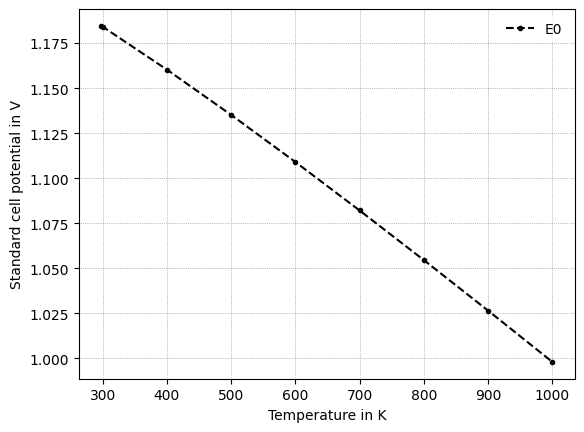

In [9]:
from phdtools.plots.fuel_cell import plot_stst_cell_potential

fig = plot_stst_cell_potential(
    fname=DataID(DataType.FIGURE, Chapter.UNUSED, 14).get_path(fail_exists=False)
    / f"{FILE_DATE}_stst_cell_potential.csv"
)

### Influence of temperature and pressure
[back](#Table-of-contents)

$$
\newcommand{\Activity}[1]{a_{#1}}
\newcommand{\PartialPressure}[1]{p_{#1}}
\newcommand{\StdPressure}{p^{\circ}}
$$
Given the stoichiometry coefficients in \eqref{eq:hor} and \eqref{eq:orr} the Nerst equation \eqref{eq:nernst} is given by
$$
\ReversibleCellPotential 
    = \StdCellPotential - \frac{\GasConst \Temperature}{\StoichiometricNumber{} \FaradayConst} \ln Q 
    = \StdCellPotential - \frac{\GasConst \Temperature}{4 \FaradayConst} \ln \frac{\Activity{\ce{H2O}}^2}{\Activity{\ce{H2}}^2 \Activity{\ce{O2}}}
$$
For an ideal gas $\Activity{i} = \PartialPressure{i} / \StdPressure$
$$
E = \StdCellPotential - \frac{\mathbf{R} T}{4\mathbf{F}}  \ln \frac{\PartialPressure{\ce{H2O}}^2 \StdPressure}{\PartialPressure{\ce{H2}}^2 \PartialPressure{\ce{O2}}}
$$

#### Feed composition
[back](#Table-of-contents)

In [10]:
from phdtools.data.thermophysical import vapourPressureModel
from phdtools.models.meck_2025 import Compound

$$
\newcommand{\DryMoleFraction}[1]{x^{\mathrm{dry}}_{#1}}
\newcommand{\MoleFraction}[1]{x_{#1}}
\newcommand{\AmountOfSubstance}[1]{N_{#1}}
\newcommand{\TotalAmountOfSubstance}{N}
\newcommand{\PartialVolume}[1]{V_{#1}}
\newcommand{\TotalVolume}{V}
$$
The feed air composition is approximated as a mixture of $\ce{N2}$, $\ce{O2}$, and $\ce{H2O(g)}$. 
According to ISO 2533:1975 (Standard Atmosphere) the dry clean air composition near sea level is 78.084 %(vol) nitrogen ($\ce{N2}$), 20.9476 %(vol) oxygen ($\ce{O2}$), 0.934 %(vol) argon ($\ce{Ar}$), 0.0314 %(vol) carbon dioxide ($\ce{CO2}$), and additional gases of lesser concentration. Modelling air as a ternary mixture of $\ce{N2}$, $\ce{O2}$, and $\ce{H2O(g)}$, we approximate their content of volume to sum to one by assuming the oxygen content remains unchanged, i.e. $\PartialVolume{\ce{N2}}/\TotalVolume = 1 − \PartialVolume{\ce{O2}}/\TotalVolume = 0.790524$. 
Assuming ideal gas behaviour, the content of volume $\PartialVolume{i}/\TotalVolume$ is equal the mole fraction $\MoleFraction{i} := \AmountOfSubstance{i}/\TotalAmountOfSubstance$.

The mole fractions $x_i$ of the mixture including water are related to the dry mole fractions as follows
$$
\MoleFraction{i} = \frac{\AmountOfSubstance{i}}{\TotalAmountOfSubstance} \implies \AmountOfSubstance{i} = \MoleFraction{i} \TotalAmountOfSubstance
$$

$$
\DryMoleFraction{i} 
    = \frac{\AmountOfSubstance{i}}{\TotalAmountOfSubstance^\mathrm{dry}} \implies 
    \AmountOfSubstance{i} = \DryMoleFraction{i} \TotalAmountOfSubstance^\mathrm{dry}
$$

$$
\begin{aligned}
    \DryMoleFraction{i} \TotalAmountOfSubstance^\mathrm{dry} &= \MoleFraction{i} \TotalAmountOfSubstance \\
    \DryMoleFraction{i} \TotalAmountOfSubstance^\mathrm{dry} &= \MoleFraction{i} ( \TotalAmountOfSubstance^\mathrm{dry} + \AmountOfSubstance{\ce{H2O(g)}}) \\
    \DryMoleFraction{i} \TotalAmountOfSubstance^\mathrm{dry} &= \MoleFraction{i} ( \TotalAmountOfSubstance^\mathrm{dry} + \MoleFraction{\ce{H2O(g)}} \TotalAmountOfSubstance ) \\
    \DryMoleFraction{i} \TotalAmountOfSubstance^\mathrm{dry} &= \MoleFraction{i} \TotalAmountOfSubstance^\mathrm{dry} + \MoleFraction{\ce{H2O(g)}} \AmountOfSubstance{i} \\
    \DryMoleFraction{i} &= \MoleFraction{i} + \MoleFraction{\ce{H2O(g)}} \DryMoleFraction{i} \\
    \MoleFraction{i} & = \DryMoleFraction{i} ( 1 - \MoleFraction{\ce{H2O(g)}})
\end{aligned}
$$

$$
\newcommand{\Pressure}{p}
\newcommand{\RelativeHumidity}{\phi}
\newcommand{\SaturationVapourPressure}[1]{p^\mathrm{sat}_{#1}}
$$
Assumming the relatvie humidity $\RelativeHumidity = \PartialPressure{\ce{H2O(g)}} / \SaturationVapourPressure{\ce{H2O(g)}} \approx 0.6$ and the pressure $\Pressure = 1.01325 \, \mathrm{bar}$, 
$$
\MoleFraction{\ce{H2O(g)}} = \RelativeHumidity \, \frac{\SaturationVapourPressure{\ce{H2O(g)}}}{\Pressure}
$$

In [11]:
dryMoleFractionAir = np.zeros(len(Compound))
moleFractionCathodeIn = np.zeros(len(Compound))

dryMoleFractionAir[Compound["O2(ref)"].value] = 0.2095
dryMoleFractionAir[Compound["N2(ref)"].value] = 0.7905

vapourPressureBar = vapourPressureModel(ISO_STD_REF_TEMPERATURE_SI) * 1e-5

display(Latex(rf"$p_\mathrm{{sat}} = {vapourPressureBar[0]:.4f}\,\mathrm{{bar}}$"))

<IPython.core.display.Latex object>

In [12]:
moleFractionCathodeIn[Compound["H2O1(g)"].value] = (
    vapourPressureBar[0] * ISO_STD_REF_REL_HUMIDITY / (1e-5 * ISO_STD_REF_PRESSURE_SI)
)
for c in Compound:
    if c.name != "H2O1(g)":
        moleFractionCathodeIn[c.value] = dryMoleFractionAir[c.value] * (
            1 - moleFractionCathodeIn[Compound["H2O1(g)"].value]
        )

In [13]:
display(Latex("Hence, it follows for the mole fractions $x_i$:"))
for c in Compound:
    display(
        Latex(rf"$x_{{\mathrm{{{c.name}}}}} = {moleFractionCathodeIn[c.value]:.4f}$")
    )

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

#### Reversible cell potential with inlet partial pressures
[back](#Table-of-contents)

> "Depending on the complexity of the model, the concentrations of reactant gases in a fuel cell can initially be expressed as the inlet partial pressure, $p_{\ce{H2},i}$ and $p_{\ce{O2},i}$ (i.e. as the feed enters the particular gas channel) or the average partial pressure in the channel." (Mann et al., 2006)

Some authors (notably the group around Amplett and Mann) take the partial pressure at the catalyst/gas interface. 
Therefore they effectively include the Nerstian mass transport losses into the reversible cell potential whereas others (for instance O’Hayre, 2016) model mass transport losses separately (Mann et al., 2006). 
> "Evaluation of the (two) partial pressures typically involves mass transfer calculations and normally requires averaging over a cell surface or along the direction of gas flow, to account for significant changes in the bulk phase partial pressures of the gaseous reactants due to reaction in the cell." (Mann et al., 2000, parentheses added)

In [14]:
from phdtools.data.thermochemical import STST_PRESSURE_BAR
from phdtools.models.ohayre_2016 import reversibleCellPotentialModel

In [15]:
temperatureKelvin = FUEL_CELL_TEMPERATURE_SI
pressureBar = ISO_STD_REF_PRESSURE_SI * 1e-5

moleFractionAnodeIn = np.zeros(len(Compound))
moleFractionAnodeIn[Compound["H2(ref)"].value] = 1

activity = np.zeros(len(Compound))

activity[Compound["H2(ref)"].value] = (
    moleFractionAnodeIn[Compound["H2(ref)"].value] * pressureBar / STST_PRESSURE_BAR
)
activity[Compound["H2O1(g)"].value] = (
    moleFractionCathodeIn[Compound["H2O1(g)"].value] * pressureBar / STST_PRESSURE_BAR
)
activity[Compound["O2(ref)"].value] = (
    moleFractionCathodeIn[Compound["O2(ref)"].value] * pressureBar / STST_PRESSURE_BAR
)

reversibleCellPotentialSI = reversibleCellPotentialModel(temperatureKelvin, activity)

Latex(
    rf"At $T_\mathrm{{FC}} = {temperatureKelvin-273.15}\,^\circ\mathrm{{C}} \ ({temperatureKelvin}\,\mathrm{{K}})$: "
    rf"reversible cell potential (with inlet partial pressures) $E = {reversibleCellPotentialSI[0]:.4f}\,\mathrm{{V}}$"
)

<IPython.core.display.Latex object>

#### Reversible cell potential with concentrations in the electrolyte film
[back](#Table-of-contents)

According to [Mamlouk, Sousa and Scott (2011)](#References) the catalyst surface is covered by a thin electrolyte film in which the reactant gases need to dissolve first. 
$
\newcommand{\MolarDensity}{c}
\newcommand{\Concentration}[1]{c_{#1}}
$
Assuming an activity coefficient close to one they suggest expressing the activities of the solutes $\ce{H2}$ and $\ce{O2}$ with their activities in an ideal solution $\Activity{i} \approx \Concentration{i} / \MolarDensity = x_i$. 
The molar density of the electrolyte is
$$
\MolarDensity = \sum_i \Concentration{i} \approx \Concentration{\ce{H2O}} + \Concentration{\ce{H3PO4}}
$$

In [16]:
from phdtools.data.thermophysical import get_molarConcentrationPhosphoricAcid

massFractionPhosphoricAcid = 0.9
temperatureKelvin = FUEL_CELL_TEMPERATURE_SI
molarDensityElectrolyteSI = get_molarConcentrationPhosphoricAcid(
    massFractionPhosphoricAcid, temperatureKelvin
)[0, 0]

Latex(
    rf"At $T_\mathrm{{FC}} = {temperatureKelvin-273.15}\,^\circ\mathrm{{C}} \ ({temperatureKelvin}\,\mathrm{{K}})$ "
    rf"and $w_\mathrm{{H_3PO_4}} = {massFractionPhosphoricAcid}$: "
    rf"$c = {molarDensityElectrolyteSI*1e-3:.4f}\,\mathrm{{mol/L}}$"
)

<IPython.core.display.Latex object>

Therefore, 
$$
\Activity{\ce{H2}} = \frac{\Concentration{\ce{H2}}}{\MolarDensity} \quad \text{and} \quad  \Activity{\ce{O2}} = \frac{\Concentration{\ce{O2}}}{\MolarDensity}
$$

the activity of water

$$
\Activity{\ce{H2O}} = \frac{\PartialPressure{\ce{H2O}}}{\SaturationVapourPressure{\ce{H2O}}} 
$$

In [17]:
# from phdtools.data.solubility import Compound, molalHenryConstModel,
from phdtools.data.thermophysical import saturatedLiquidWaterDensityModel
from phdtools.data.solubility import molarOxygenSolubilityInH3PO4, STD_CONCENTRATION_SI

##### Relative humidity according to ISO standard reference conditions

In [18]:
from phdtools.models.mamlouk_sousa_scott_2011 import get_electrolyteFilmActivities

temperatureKelvin = FUEL_CELL_TEMPERATURE_SI
pressureBar = ISO_STD_REF_PRESSURE_SI * 1e-5
massFractionPhosphoricAcid = 0.9

moleFractionAnodeIn = np.zeros(len(Compound))
moleFractionCathodeIn = np.zeros(len(Compound))

moleFractionAnodeIn[Compound["H2(ref)"].value] = 1

inletVapourPressureBar = (
    vapourPressureModel(ISO_STD_REF_TEMPERATURE_SI)[0] * 1e-5 * ISO_STD_REF_REL_HUMIDITY
)

moleFractionCathodeIn[Compound["H2O1(g)"].value] = (
    inletVapourPressureBar
) / pressureBar

for c in Compound:
    if c.name != "H2O1(g)":
        moleFractionCathodeIn[c.value] = dryMoleFractionAir[c.value] * (
            1 - moleFractionCathodeIn[Compound["H2O1(g)"].value]
        )

activity = get_electrolyteFilmActivities(
    moleFractionAnodeIn,
    moleFractionCathodeIn,
    temperatureKelvin,
    pressureBar,
    massFractionPhosphoricAcid,
)

In [19]:
reversibleCellPotentialSI = reversibleCellPotentialModel(temperatureKelvin, activity)

display(
    Latex(
        rf"Taking the water vapour pressure $p_\mathrm{{H_2O}} = {inletVapourPressureBar:.4f}\,\mathrm{{bar}}$ at inlet conditions "
        rf"$T_\mathrm{{ISO}} = {ISO_STD_REF_TEMPERATURE_SI}\,\mathrm{{K}}$; $\phi_\mathrm{{ISO}} = {ISO_STD_REF_REL_HUMIDITY}$ (and assuming perfect gas activity), "
    ),
    Latex(
        rf"with $T_\mathrm{{FC}} = {temperatureKelvin-273.15}\,^\circ\mathrm{{C}} \ ({temperatureKelvin}\,\mathrm{{K}})$ "
        rf"and $w_\mathrm{{H_3PO_4}} = {massFractionPhosphoricAcid}$ "
        rf" the reversible cell potential (with concentrations in the electrolyte film) is $E = {reversibleCellPotentialSI[0]:.4f}\,\mathrm{{V}}$. "
    ),
)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

##### Relative humidity maintaining constant $\ce{H3PO4}$ concentration

In [20]:
from phdtools.data.thermophysical import (
    get_moleFractionH3PO4,
    waterVapourPressureOverH3PO4Model,
)

In [21]:
temperatureKelvin = FUEL_CELL_TEMPERATURE_SI
pressureBar = ISO_STD_REF_PRESSURE_SI * 1e-5
massFractionPhosphoricAcid = 0.9

vapourPressureOverPhosphoricAcid = (
    waterVapourPressureOverH3PO4Model(
        moleFractionH3PO4=get_moleFractionH3PO4(massFractionPhosphoricAcid),
        temperatureKelvin=temperatureKelvin,
    )[0, 0]
    * 1e-5
)

display(
    Latex(
        rf"At $T_\mathrm{{FC}} = {temperatureKelvin-273.15}\,^\circ\mathrm{{C}} \ ({temperatureKelvin}\,\mathrm{{K}})$ "
        rf"and $w_\mathrm{{H_3PO_4}} = {massFractionPhosphoricAcid}$ "
        rf"the saturation water vapour pressure over concentrated $\mathrm{{H_3PO_4}}$ solution is $p^\mathrm{{sat}}_\mathrm{{H_2O,H_3PO_4}} = {vapourPressureOverPhosphoricAcid:.4f}\,\mathrm{{bar}}$"
    )
)

<IPython.core.display.Latex object>

In [22]:
temperatureKelvin = FUEL_CELL_TEMPERATURE_SI
pressureBar = ISO_STD_REF_PRESSURE_SI * 1e-5

vapourPressureBar = vapourPressureModel(temperatureKelvin)[0] * 1e-5

Latex(
    rf"At $T_\mathrm{{FC}} = {temperatureKelvin-273.15}\,^\circ\mathrm{{C}} \ ({temperatureKelvin}\,\mathrm{{K}})$ "
    rf"the saturation water vapour pressure over pure water is $p_\mathrm{{H_2O,pure}}^\mathrm{{sat}} = {vapourPressureBar:.4f}\,\mathrm{{bar}}$"
)

<IPython.core.display.Latex object>

In [23]:
temperatureKelvin = FUEL_CELL_TEMPERATURE_SI
pressureBar = ISO_STD_REF_PRESSURE_SI * 1e-5
massFractionPhosphoricAcid = 0.9

moleFractionAnodeIn = np.zeros(len(Compound))
moleFractionCathodeIn = np.zeros(len(Compound))

moleFractionAnodeIn[Compound["H2(ref)"].value] = 1
moleFractionCathodeIn[Compound["H2O1(g)"].value] = (
    vapourPressureModel(ISO_STD_REF_TEMPERATURE_SI)[0] * 1e-5 * ISO_STD_REF_REL_HUMIDITY
) / pressureBar

for c in Compound:
    if c.name != "H2O1(g)":
        moleFractionCathodeIn[c.value] = dryMoleFractionAir[c.value] * (
            1 - moleFractionCathodeIn[Compound["H2O1(g)"].value]
        )

activity = get_electrolyteFilmActivities(
    moleFractionAnodeIn,
    moleFractionCathodeIn,
    temperatureKelvin,
    pressureBar,
    massFractionPhosphoricAcid,
)

vapourPressureOverPhosphoricAcidBar = (
    waterVapourPressureOverH3PO4Model(
        moleFractionH3PO4=get_moleFractionH3PO4(massFractionPhosphoricAcid),
        temperatureKelvin=temperatureKelvin,
    )[0, 0]
    * 1e-5
)

activity[Compound["H2O1(g)"].value] = vapourPressureOverPhosphoricAcidBar / (
    vapourPressureModel(temperatureKelvin)[0] * 1e-5
)

reversibleCellPotentialSI = reversibleCellPotentialModel(temperatureKelvin, activity)

display(
    Latex(
        rf"Taking the water vapour pressure $p_\mathrm{{H_2O}} = p^\mathrm{{sat}}_\mathrm{{H_2O,H_3PO_4}} = {vapourPressureOverPhosphoricAcid:.4f}\,\mathrm{{bar}}$ at "
        rf"$T_\mathrm{{FC}} = {FUEL_CELL_TEMPERATURE_SI}\,\mathrm{{K}}$ (which would maintain a constant electrolyte concentration), "
    ),
    Latex(
        rf"with $T_\mathrm{{FC}} = {temperatureKelvin-273.15}\,^\circ\mathrm{{C}} \ ({temperatureKelvin}\,\mathrm{{K}})$ "
        rf"and $w_\mathrm{{H_3PO_4}} = {massFractionPhosphoricAcid}$ "
        rf" the reversible cell potential (with concentrations in the electrolyte film) is $E = {reversibleCellPotentialSI[0]:.4f}\,\mathrm{{V}}$. "
    ),
)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

#### Reversible cell potential vs. temperature
[back](#Table-of-contents)

In [24]:
from phdtools.models.ohayre_2016 import stdCellPotentialModel

# request_free_id(DataType.FIGURE, Chapter.UNUSED)

In [25]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 15)

temperatureRange = np.linspace(0, 200, 41) + 273.15
pressureRange = 1e-5 * ISO_STD_REF_PRESSURE_SI * np.array([1, 2, 5])
massFractionPhosphoricAcid = 0.9

stdCellPotentialValues = stdCellPotentialModel(temperatureRange, method="interpolate")

reversibleCellPotentialValues = np.zeros((3, len(temperatureRange)))
reversibleCellPotentialValues[:] = np.nan

for num, pressureBar in enumerate(pressureRange):

    # Determine the inlet composition
    moleFractionAnodeIn = np.zeros(len(Compound))
    moleFractionCathodeIn = np.zeros(len(Compound))

    moleFractionAnodeIn[Compound["H2(ref)"].value] = 1
    moleFractionCathodeIn[Compound["H2O1(g)"].value] = (
        vapourPressureModel(ISO_STD_REF_TEMPERATURE_SI)[0]
        * 1e-5
        * ISO_STD_REF_REL_HUMIDITY
    ) / pressureBar

    for c in Compound:
        if c.name != "H2O1(g)":
            moleFractionCathodeIn[c.value] = dryMoleFractionAir[c.value] * (
                1 - moleFractionCathodeIn[Compound["H2O1(g)"].value]
            )

    activity = get_electrolyteFilmActivities(
        moleFractionAnodeIn,
        moleFractionCathodeIn,
        temperatureKelvin,
        pressureBar,
        massFractionPhosphoricAcid,
    )

    reversibleCellPotentialValues[num] = reversibleCellPotentialModel(
        temperatureRange, activity
    )

    # Activity of the solvent
    vapourPressureOverPhosphoricAcidBar = (
        waterVapourPressureOverH3PO4Model(
            moleFractionH3PO4=get_moleFractionH3PO4(massFractionPhosphoricAcid),
            temperatureKelvin=temperatureKelvin,
        )[0, 0]
        * 1e-5
    )

    activity[Compound["H2O1(g)"].value] = vapourPressureOverPhosphoricAcidBar / (
        vapourPressureModel(temperatureKelvin)[0] * 1e-5
    )

    reversibleCellPotentialSI = reversibleCellPotentialModel(
        temperatureKelvin, activity
    )

description = (
    (
        "Reversible cell potential E for different values of temperature T and pressure p following Mamlouk, Sousa and Scott (2011). \n"
        "The standard potential E0 was computed from tabulated data for the Gibbs free energy of formation from Allison (2013) and linearly interpolated; see Atkins (2023). \n"
        f"The values (E) assume a constant concentration (mass fraction w_H3PO4 = {massFractionPhosphoricAcid}) in the electrolyte film,\n"
        "by setting the water vapour pressure p_H2O to the saturation vapour pressure over concentrated H3PO4 solution at the cell temperature T, \n"
        "which is calculated from MacDonald and Boyack (1969).\n"
        "The activities of the solutes were computed as outlined in Mamlouk, Sousa and Scott (2011) considering the oxygen solubility (Klinedinst et al., 1974)"
        "and molar density (MacDonald and Boyack, 1969) of the concentrated electrolyte film based on the inlet mole fractions listed below."
        "\n"
        "Feed composition:\n"
        "----------------- \n"
        "  Anode:  "
    )
    + (";".join(f" x[{c.name}] = {moleFractionAnodeIn[c.value]}" for c in Compound))
    + ("  Cathode:")
    + (";".join(f" x[{c.name}] = {moleFractionCathodeIn[c.value]}" for c in Compound))
    + (
        "\n"
        "References: \n"
        "----------- \n"
        "Allison, T. (2013) ‘NIST-JANAF Thermochemical Tables - SRD 13’.\n"
        "    National Institute of Standards and Technology. Available at: https://doi.org/10.18434/T42S31 \n"
        "\n"
        "Atkins, P.W., Paula, J.D. and Keeler, J. (2023) Atkins’ Physical chemistry. Twelfth edition. \n"
        "    New York NY: Oxford University Press."
        "\n"
        "Klinedinst, K. et al. (1974) “Oxygen solubility and diffusivity in hot concentrated H3PO4,” Journal \n"
        "   of Electroanalytical Chemistry and Interfacial Electrochemistry, 57(3), pp. 281–289. Available at: \n"
        "   https://doi.org/10.1016/S0022-0728(74)80053-7\n."
        "\n"
        "Mamlouk, M., Sousa, T. and Scott, K. (2011) “A High Temperature Polymer Electrolyte Membrane Fuel\n"
        "    Cell Model for Reformate Gas,” International Journal of Electrochemistry, 2011, pp. 1–18. \n"
        "    Available at: https://doi.org/10.4061/2011/520473.\n"
        "\n"
        "MacDonald, D.I. and Boyack, J.R. (1969) “Density, electrical conductivity, and vapor pressure of \n"
        "    concentrated phosphoric acid,” Journal of Chemical & Engineering Data, 14(3), pp. 380–384. \n"
        "    Available at: https://doi.org/10.1021/je60042a013.\n"
    )
)


@auto_create_path
def save_reverible_cell_potential(path):
    fname = path / f"{TODAY}_reversible_cell_potential.csv"
    with open(fname, "w+") as f:
        write_metadata(f, description)
        np.savetxt(
            f,
            np.c_[
                temperatureRange,
                stdCellPotentialValues,
                reversibleCellPotentialValues.T,
            ],
            header="T(K),E0(V),"
            + ",".join(f"E{{{p:.4f} bar}}(V)" for p in pressureRange),
            comments="",
            delimiter=",",
        )


save_reverible_cell_potential(
    data_id,
    doc=r"Reversible cell potential for different values of temperature and pressure following \textcite{Mamlouk.2011a}",
    overwrite=overwrite,
)

In [26]:
!ls {DataID(DataType.FIGURE, Chapter.UNUSED, 15).get_path(fail_exists=False)}

260407_reversible_cell_potential.csv


In [27]:
fname = (
    DataID(DataType.FIGURE, Chapter.UNUSED, 15).get_path(fail_exists=False)
    / f"{FILE_DATE}_reversible_cell_potential.csv"
)

pd.read_csv(fname, comment="#", index_col=0).head()

,E0(V),E{1.0132 bar}(V),E{2.0265 bar}(V),E{5.0663 bar}(V)
T(K),,,,
273.15,1.184543,1.055564,1.067831,1.084025
278.15,1.184543,1.053203,1.065694,1.082185
283.15,1.184543,1.050842,1.063558,1.080345
288.15,1.184543,1.048481,1.061421,1.078505
293.15,1.184543,1.046120,1.059285,1.076665


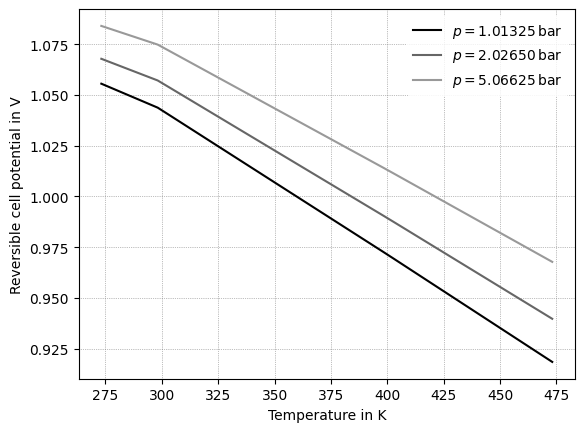

In [28]:
from phdtools.plots.fuel_cell import plot_reversible_cell_potential_vs_temperature

_ = plot_reversible_cell_potential_vs_temperature(
    DataID(DataType.FIGURE, Chapter.UNUSED, 15).get_path(fail_exists=False)
    / f"{FILE_DATE}_reversible_cell_potential.csv"
)

## Real fuel cell performace
[back](#Table-of-contents)

$$
\newcommand{\ActivationOverpotential}[1]{\eta_{\mathrm{act},#1}}
\newcommand{\AreaSpecificResistance}[1]{R_{s}}
\newcommand{\CurrentDensity}{j}
\CellPotential = \ReversibleCellPotential + \ActivationOverpotential{R} - \ActivationOverpotential{L} - \eta_\mathrm{conc} - \AreaSpecificResistance{} \CurrentDensity
$$

### Activation overpotential
[back](#Table-of-contents)

$$
\newcommand{\GasConst}{\mathbf{R}}
\newcommand{\FaradayConst}{\mathbf{F}}
\newcommand{\Temperature}{T}
\newcommand{\ElectronsTransferred}{\nu}
\newcommand{\TransferCoef}{\alpha}
\newcommand{\ExchangeCurrentDensity}{j_0}
\newcommand{\ActivationLosses}{\eta_\mathrm{act}}
\newcommand{\Concentration}[2]{c_{#1}^{#2}}
\newcommand{\ActivationEnergy}[1]{E_{#1}}
\ActivationLosses = \eta_\mathrm{act,R} - \eta_\mathrm{act,L}
$$

**Butler-Volmer Equation** Relates *activation overvoltage* $\ActivationLosses$ to current density

$$
\CurrentDensity{}
    = \ExchangeCurrentDensity
    \left[
      \exp{
        \left(
          (1 - \TransferCoef) 
          \frac
          {\ElectronsTransferred{}\FaradayConst\ActivationLosses}
          {\GasConst\Temperature{}}
        \right)
      } 
      - \exp{
        \left(
          -\TransferCoef
          \frac
          {\ElectronsTransferred{}\FaradayConst\ActivationLosses}
          {\GasConst\Temperature{}}
        \right)
      } 
    \right]
$$

$\ExchangeCurrentDensity$: exchange current density; represents the rate of exchange between reactant and product state at equilibrium. 


#### Temperature dependence of the exchange current density
[back](#Table-of-contents)

$$
\ExchangeCurrentDensity(\Temperature) = A \exp{\left(-\frac{\ActivationEnergy{}}{\GasConst{}\Temperature{}}\right)}
\implies
\ln{\ExchangeCurrentDensity} =  \ln{A} - \frac{\ActivationEnergy{}}{\GasConst{}\Temperature{}}
$$

In [29]:
from phdtools.models.zhang_2007 import fit_exchangeCurrentDensityModel, ModelParameters

In [30]:
!ls {DATA_DIR / "zhang-2007" }

251020_polarization_curve.csv 2511102_table2.csv
2511102_table1.csv


In [31]:
fname = DATA_DIR / "zhang-2007" / "2511102_table1.csv"

df = pd.read_csv(fname, usecols=[0, 1, 2, 3, 4])
df["T(K)"] = df["Temperature (C)"] + 273.15
df = df.drop("Temperature (C)", axis=1).set_index("T(K)")
df

,"i^0_O2, apparent (A cm-2)","I^0_O2(Pt/PtO), intrinsic (A cm-2)","i^0_H2, apparent (A cm-2)","I^0_H2, intrinsic (A cm-2)"
T(K),,,,
393.15,0.00230,0.000090,0.72,0.0102
413.15,0.00205,0.000105,1.24,0.0218
433.15,0.00264,0.000151,1.88,0.0351
453.15,0.00360,0.000318,2.50,0.0682
473.15,0.00543,0.000788,2.71,0.1160


In [32]:
model = fit_exchangeCurrentDensityModel(
    fname=DATA_DIR / "zhang-2007" / "2511102_table1.csv"
)
model

,Tr (K),j0[Tr] (A/cm2),E (kJ/mol),R2
"i^0_O2, apparent (A cm-2)",433.15,0.003063027188309525,17.208738566829272,0.802666
"I^0_O2(Pt/PtO), intrinsic (A cm-2)",433.15,0.00021470521996748784,41.43297715204728,0.88911
"i^0_H2, apparent (A cm-2)",433.15,1.6778864711212782,26.254106110978764,0.957615
"I^0_H2, intrinsic (A cm-2)",433.15,0.038209882266741664,46.44171168633971,0.996747


In [33]:
params = ModelParameters.init()
pprint(params)

ModelParameters(exchangeCurrentDensitySIRef=array([16778.86471121,    30.63027188]),
                activationEnergyExchangeCurrentDensitySI=array([26254.10611098, 17208.73856683]),
                refTemperatureExchangeCurrentDensitySI=array([433.15, 433.15]),
                preExponentialFactorConductivitySI=np.float64(4902080.113638175),
                activationEnergyConductivitySI=np.float64(19900.0))


In [34]:
from phdtools.models.zhang_2007 import exchangeCurrentDensityModel

exchangeCurrentDensitySIValues = exchangeCurrentDensityModel(params, 160 + 273.15)
exchangeCurrentDensitySIValues * 1e-4

array([[1.67788647, 0.00306303]])

In [35]:
import scipy

# request_free_id(DataType.FIGURE, Chapter.UNUSED)

In [36]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 16)


@auto_create_path
def save_exchange_current_density_model(path):
    fname = path / f"{TODAY}_exchange_current_density_model.csv"
    with open(fname, "w+") as f:

        params = ModelParameters.init()

        temperatureRangeSI = np.linspace(120, 200) + 273.15
        exchangeCurrentDensitySIValues = exchangeCurrentDensityModel(
            params, temperatureRangeSI
        )

        # Model values
        description = (
            f"Values for the apparent exchange current density j0 in A/cm2\n"
            f"for the HOR (A) and ORR (C) at different temperatures T in Kelvin. \n"
            f"The values below were computed from an Arrhenius model in the form of \n"
            f"\n"
            f"    j0(T) = j0(Tr) * exp( -E/(RT) (1/T - 1/Tr) )\n"
            f"\n"
            f"The parameters j0(Tr), and E were estimated via a linear regression model,\n"
            f"using the 'LinearRegression' model from sklearn.linear_model (scipy {scipy.__version__}) based on \n"
            f"experimental data from (Zhang et al., 2007).\n"
            f"The measurements were performed at ambient backpressure operated in air (dry) using pure hydrogen\n"
            f"(the concrete values of the concentrations are unkown).\n"
            f"The parameter values are: \n"
            f"   Anode: j0,A(Tr) = {params.exchangeCurrentDensitySIRef[0]*1e-4:.4f} A/cm2, E_A = {params.activationEnergyExchangeCurrentDensitySI[0]*1e-3:.2f} kJ/mol, Tr = {params.refTemperatureExchangeCurrentDensitySI[0]:.2f} K\n"
            f"   Cathode: j0,C(Tr) = {params.exchangeCurrentDensitySIRef[1]*1e-4:.4f} A/cm2, E_C = {params.activationEnergyExchangeCurrentDensitySI[1]*1e-3:.2f} kJ/mol, Tr = {params.refTemperatureExchangeCurrentDensitySI[1]:.2f} K\n"
            f"\n"
            f"References: \n"
            f"----------- \n"
            f"Zhang, Jianlu et al. (2007) “Polybenzimidazole-membrane-based PEM fuel cell\n"
            f"    in the temperature range of 120–200 °C,” Journal of Power Sources, 172(1),\n"
            f"    pp. 163–171. Available at: https://doi.org/10.1016/j.jpowsour.2007.07.047."
            f'Virtanen, P. et al. (2020) "SciPy 1.0: fundamental algorithms for scientific \n'
            f'    computing in Python," Nature Methods, 17(3), pp. 261–272. \n'
            f"    Available at: https://doi.org/10.1038/s41592-019-0686-2.\n"
        )
        write_metadata(f, description)
        np.savetxt(
            f,
            np.c_[temperatureRangeSI, exchangeCurrentDensitySIValues * 1e-4],
            header='"T(K)","j0,A(Acm-2)","j0,C(Acm-2)"',
            delimiter=",",
            comments="",
            fmt=["%.2f", "%.18e", "%.18e"],
        )


save_exchange_current_density_model(
    data_id,
    doc=r"Temperature dependence of the apparent exchange current density determined from \textcite{Zhang.2007b}",
    overwrite=overwrite,
)

In [37]:
!ls {DataID(DataType.FIGURE, Chapter.UNUSED, 16).get_path(fail_exists=False)}

260407_exchange_current_density_model.csv


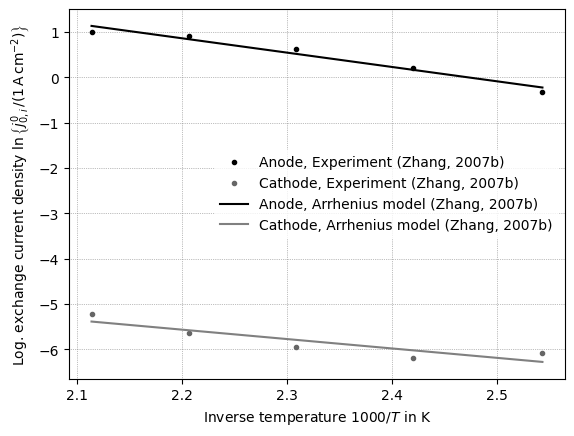

In [38]:
from phdtools.plots.fuel_cell import plot_arrhenius_model_exchange_current_density

fig = plot_arrhenius_model_exchange_current_density(
    fname_data=DATA_DIR / "zhang-2007" / "2511102_table1.csv",
    fname_model=DataID(DataType.FIGURE, Chapter.UNUSED, 16).get_path(fail_exists=False)
    / f"{FILE_DATE}_exchange_current_density_model.csv",
)

#### Butler-Volmer overpotential at the anode and cathode
[back](#Table-of-contents)

In [39]:
from phdtools.models.zhang_2007 import (
    transferCoefModel,
    ELECTRONS_TRANSFERRED_HOR,
    ELECTRONS_TRANSFERRED_ORR,
)

temperatureKelvin = FUEL_CELL_TEMPERATURE_SI
pressureBar = ISO_STD_REF_PRESSURE_SI * 1e-5

transferCoefModel(temperatureKelvin)

array([[0.5      , 0.6597057]])

In [40]:
from phdtools.models.ohayre_2016 import activationOverpotentialModel

currentDensitySI = 1e4
temperatureKelvin = FUEL_CELL_TEMPERATURE_SI
pressureBar = ISO_STD_REF_PRESSURE_SI * 1e-5

transferCoefficientHOR = transferCoefModel(temperatureKelvin)[:, 0][0]
transferCoefficientORR = transferCoefModel(temperatureKelvin)[:, 1][0]
exchangeCurrentDensityHORSI = exchangeCurrentDensityModel(params, temperatureKelvin)[
    :, 0
][0]
exchangeCurrentDensityORRSI = exchangeCurrentDensityModel(params, temperatureKelvin)[
    :, 1
][0]

activationOverpotentialAnodeSI = activationOverpotentialModel(
    currentDensitySI=2e4,
    temperatureKelvin=temperatureKelvin,
    transferCoefficient=transferCoefficientHOR,
    exchangeCurrentDensitySI=exchangeCurrentDensityHORSI,
    electronsTransferred=ELECTRONS_TRANSFERRED_HOR,
    model="butler-volmer",
)[0]

activationOverpotentialCathodeSI = activationOverpotentialModel(
    currentDensitySI=-2e4,
    temperatureKelvin=temperatureKelvin,
    transferCoefficient=transferCoefficientORR,
    exchangeCurrentDensitySI=exchangeCurrentDensityORRSI,
    electronsTransferred=ELECTRONS_TRANSFERRED_ORR,
    model="butler-volmer",
)[0]

display(
    Latex(rf"At $T = {temperatureKelvin-273.15} \, ^\circ\mathrm{{C}}$:"),
    Latex(
        rf"$\eta_\mathrm{{act,A}}({currentDensitySI*1e-4:.1f}\,\mathrm{{A}}) = {activationOverpotentialAnodeSI:.4f} \, \mathrm{{V}}$, "
        rf"where $\alpha_\mathrm{{HOR}} = {transferCoefficientHOR:.2f}$ and $n_\mathrm{{HOR}} = {ELECTRONS_TRANSFERRED_HOR:d}$"
    ),
    Latex(
        rf"$\eta_\mathrm{{act,C}}({currentDensitySI*1e-4:.1f}\,\mathrm{{A}}) = {activationOverpotentialCathodeSI:.4f} \, \mathrm{{V}}$, "
        rf"where $\alpha_\mathrm{{ORR}} = {transferCoefficientORR:.2f}$ and $n_\mathrm{{ORR}} = {ELECTRONS_TRANSFERRED_ORR:d}$"
    ),
)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [41]:
activationOverpotentialAnodeSI = activationOverpotentialModel(
    currentDensitySI=exchangeCurrentDensityHORSI,
    temperatureKelvin=temperatureKelvin,
    transferCoefficient=transferCoefficientHOR,
    exchangeCurrentDensitySI=exchangeCurrentDensityHORSI,
    electronsTransferred=ELECTRONS_TRANSFERRED_HOR,
    model="tafel",
)[0]
np.log10(exchangeCurrentDensityHORSI * 1e-4)
# activationOverpotentialAnodeSI

np.float64(-0.09735228367116561)

#### Single term Butler-Volmer approximation (Tafel equation)
[back](#Table-of-contents)

For high activation overpotential $\lvert\ActivationLosses\rvert$ the Butler-Volmer Equation can be approximated with a single term
where for $\CurrentDensity{} < 0$ (cathodic) and large negative $\ActivationLosses$, 
$$
\CurrentDensity = -\ExchangeCurrentDensity \exp{
        \left(
          -\TransferCoef
          \frac
          {\ElectronsTransferred{}\FaradayConst\ActivationLosses}
          {\GasConst\Temperature{}}
        \right)
      } 
\implies
\ActivationLosses 
    = -\frac
          {\GasConst\Temperature{}}
          {\TransferCoef\ElectronsTransferred{}\FaradayConst} 
      \ln{\left(-\frac{\CurrentDensity}{\ExchangeCurrentDensity}\right)} 
     = 
      -\ln{(10)}\frac
          {\GasConst\Temperature{}}
      {\TransferCoef\ElectronsTransferred{}\FaradayConst} 
      \log_{10}{\left(-\frac{\CurrentDensity}{\ExchangeCurrentDensity}\right)} 
$$
and for $\CurrentDensity{} > 0$ (anodic) and large positive $\ActivationLosses$, 
$$
\CurrentDensity = \ExchangeCurrentDensity \exp{
        \left(
          (1-\TransferCoef)
          \frac
          {\ElectronsTransferred{}\FaradayConst\ActivationLosses}
          {\GasConst\Temperature{}}
        \right)
      } 
\implies
\ActivationLosses = 
          \frac
          {\GasConst\Temperature{}}
          {(1 - \TransferCoef)\ElectronsTransferred{}\FaradayConst}
          \ln{\left(\frac{\CurrentDensity}{\ExchangeCurrentDensity}\right)} 
$$

##### Dimensionless overpotential

According to [Stuve (2014)](#References), the approximation is valid for 

$$
\frac
    {\ElectronsTransferred{}\FaradayConst\ActivationOverpotential{}}
    {\GasConst\Temperature{}} 
    \gtrsim 3.2
$$

In [42]:
temperatureKelvin = FUEL_CELL_TEMPERATURE_SI

transferCoefficientHOR = transferCoefModel(temperatureKelvin)[:, 0][0]
transferCoefficientORR = transferCoefModel(temperatureKelvin)[:, 1][0]
exchangeCurrentDensityHORSI = exchangeCurrentDensityModel(params, temperatureKelvin)[
    :, 0
][0]
exchangeCurrentDensityORRSI = exchangeCurrentDensityModel(params, temperatureKelvin)[
    :, 1
][0]


display(
    Latex(
        r"ORR: $j \geq {:.4f} \mathrm{{A/cm^2}}$".format(
            1e-4
            * exchangeCurrentDensityORRSI
            * (
                np.exp((1 - transferCoefficientORR) * 3.2)
                - np.exp(-transferCoefficientORR * 3.2)
            )
        )
    ),
    # Latex(r"HOR: $j \geq {:.4f} \mathrm{{A/cm^2}}$".format(1e-4 * exchangeCurrentDensityHORSI * (np.exp((1-transferCoefficientHOR) * 3.2) - np.exp(-transferCoefficientHOR * 3.2))))
)

<IPython.core.display.Latex object>

##### Tafel slopes

In [43]:
temperatureKelvin = 150 + 273.15
transferCoefficientHOR = transferCoefModel(temperatureKelvin)[:, 0][0]
transferCoefficientORR = transferCoefModel(temperatureKelvin)[:, 1][0]

display(
    Latex(
        "For the HOR: "
        + r"cathodic tafel slope: ${:.4f} \, \mathrm{{mV/dec}}$, ".format(
            -np.log(10)
            * GAS_CONST_SI
            * temperatureKelvin
            / (transferCoefficientHOR * ELECTRONS_TRANSFERRED_HOR * FARADAY_CONST_SI)
            * 1e3
        )
        + r"anodic tafel slope: ${:.4f} \, \mathrm{{mV/dec}}$ ".format(
            np.log(10)
            * GAS_CONST_SI
            * temperatureKelvin
            / (
                (1 - transferCoefficientHOR)
                * ELECTRONS_TRANSFERRED_HOR
                * FARADAY_CONST_SI
            )
            * 1e3
        )
    ),
    Latex(
        "For the ORR: "
        + r"cathodic tafel slope: ${:.4f} \, \mathrm{{mV/dec}}$, ".format(
            -np.log(10)
            * GAS_CONST_SI
            * temperatureKelvin
            / (transferCoefficientORR * ELECTRONS_TRANSFERRED_ORR * FARADAY_CONST_SI)
            * 1e3
        )
        + r"anodic tafel slope: ${:.4f} \, \mathrm{{mV/dec}}$ ".format(
            np.log(10)
            * GAS_CONST_SI
            * temperatureKelvin
            / (
                (1 - transferCoefficientORR)
                * ELECTRONS_TRANSFERRED_ORR
                * FARADAY_CONST_SI
            )
            * 1e3
        )
    ),
)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [44]:
data_id = DataID(DataType.FIGURE, Chapter.METHODS, 15)


@auto_create_path
def save_tafel_plot(path):
    params = ModelParameters.init()

    # pressureBar = ISO_STD_REF_PRESSURE_SI * 1e-5
    currentDensityRangeSI = (
        np.r_[
            -np.power(10, np.linspace(-6, 2, 100)),
            np.power(10, np.linspace(-6, 2, 100)),
        ]
        * 1e4
    )

    temperatureRangeSI = np.array([120, 140, 160, 180, 200]) + 273.15

    transferCoefficientHOR = transferCoefModel(temperatureRangeSI)[:, 0]
    transferCoefficientORR = transferCoefModel(temperatureRangeSI)[:, 1]
    exchangeCurrentDensityHORSI = exchangeCurrentDensityModel(
        params, temperatureRangeSI
    )[:, 0]
    exchangeCurrentDensityORRSI = exchangeCurrentDensityModel(
        params, temperatureRangeSI
    )[:, 1]

    activationOverpotentialButlerVolmerAnodeSI = np.full(
        (len(temperatureRangeSI), len(currentDensityRangeSI)), np.nan
    )
    activationOverpotentialTafelAnodeSI = np.full(
        (len(temperatureRangeSI), len(currentDensityRangeSI)), np.nan
    )
    activationOverpotentialButlerVolmerCathodeSI = np.full(
        (len(temperatureRangeSI), len(currentDensityRangeSI)), np.nan
    )
    activationOverpotentialTafelCathodeSI = np.full(
        (len(temperatureRangeSI), len(currentDensityRangeSI)), np.nan
    )

    for num, temperatureKelvin in enumerate(temperatureRangeSI):

        activationOverpotentialButlerVolmerAnodeSI[num] = activationOverpotentialModel(
            currentDensitySI=currentDensityRangeSI,
            temperatureKelvin=temperatureKelvin,
            transferCoefficient=transferCoefficientHOR[num],
            exchangeCurrentDensitySI=exchangeCurrentDensityHORSI[num],
            electronsTransferred=ELECTRONS_TRANSFERRED_HOR,
            model="butler-volmer",
        )

        activationOverpotentialTafelAnodeSI[num] = activationOverpotentialModel(
            currentDensitySI=currentDensityRangeSI,
            temperatureKelvin=temperatureKelvin,
            transferCoefficient=transferCoefficientHOR[num],
            exchangeCurrentDensitySI=exchangeCurrentDensityHORSI[num],
            electronsTransferred=ELECTRONS_TRANSFERRED_HOR,
            model="tafel",
        )

        activationOverpotentialButlerVolmerCathodeSI[num] = (
            activationOverpotentialModel(
                currentDensitySI=currentDensityRangeSI,
                temperatureKelvin=temperatureKelvin,
                transferCoefficient=transferCoefficientORR[num],
                exchangeCurrentDensitySI=exchangeCurrentDensityORRSI[num],
                electronsTransferred=ELECTRONS_TRANSFERRED_ORR,
                model="butler-volmer",
            )
        )

        activationOverpotentialTafelCathodeSI[num] = activationOverpotentialModel(
            currentDensitySI=currentDensityRangeSI,
            temperatureKelvin=temperatureKelvin,
            transferCoefficient=transferCoefficientORR[num],
            exchangeCurrentDensitySI=exchangeCurrentDensityORRSI[num],
            electronsTransferred=ELECTRONS_TRANSFERRED_ORR,
            model="tafel",
        )

    fname = path / f"{TODAY}_butler_volmer_hor_model.csv"
    with open(fname, "w+") as f:
        description = (
            (
                f"Activation overpotential (Butler-Volmer) for the HOR at different termperatures T.\n"
                f"Exchange current denisity, transfer number and coefficients\n"
                f"are modelled after Zhang, Jianlu et al. (2007). Activation overpotential is given in V.\n"
                f"The parameters were:\n"
                f"  exchange current density j0\n"
            )
            + "\n".join(
                f"    j0(T={T} K) = {exchangeCurrentDensityHORSI[num]*1e-4:.4f} A/cm2"
                for num, T in enumerate(temperatureRangeSI)
            )
            + "\n"
            + " transfer coefficient a(T)\n"
            + "\n".join(
                f"    a(T={T} K) = {transferCoefficientHOR[num]:.4f}"
                for num, T in enumerate(temperatureRangeSI)
            )
            + "\n"
            + (
                f" number of electrons transferred per reaction event n = {ELECTRONS_TRANSFERRED_HOR:.4f}\n"
                f"\n"
                f"References: \n"
                f"----------- \n"
                f"Zhang, Jianlu et al. (2007) “Polybenzimidazole-membrane-based PEM fuel cell\n"
                f"  in the temperature range of 120–200 °C,” Journal of Power Sources, 172(1),\n"
                f"  pp. 163–171. Available at: https://doi.org/10.1016/j.jpowsour.2007.07.047."
            )
        )
        write_metadata(f, description)
        np.savetxt(
            f,
            np.c_[
                currentDensityRangeSI * 1e-4,
                activationOverpotentialButlerVolmerAnodeSI.T,
            ],
            header="j(Acm-2)," + ",".join(f"{T}" for T in temperatureRangeSI),
            delimiter=",",
            comments="",
        )

    fname = path / f"{TODAY}_tafel_hor_model.csv"
    with open(fname, "w+") as f:
        description = (
            (
                f"Activation overpotential (Tafel) for the HOR at different termperatures T.\n"
                f"Exchange current denisity, transfer number and coefficients\n"
                f"are modelled after Zhang, Jianlu et al. (2007). Activation overpotential is given in V.\n"
                f"The parameters were:\n"
                f"  exchange current density j0\n"
            )
            + "\n".join(
                f"    j0(T={T} K) = {exchangeCurrentDensityHORSI[num]*1e-4:.4f} A/cm2"
                for num, T in enumerate(temperatureRangeSI)
            )
            + "\n"
            + " transfer coefficient a(T)\n"
            + "\n".join(
                f"    a(T={T} K) = {transferCoefficientHOR[num]:.4f}"
                for num, T in enumerate(temperatureRangeSI)
            )
            + "\n"
            + (
                f" number of electrons transferred per reaction event n = {ELECTRONS_TRANSFERRED_HOR:.4f}\n"
                f"\n"
                f"References: \n"
                f"----------- \n"
                f"Zhang, Jianlu et al. (2007) “Polybenzimidazole-membrane-based PEM fuel cell\n"
                f"  in the temperature range of 120–200 °C,” Journal of Power Sources, 172(1),\n"
                f"  pp. 163–171. Available at: https://doi.org/10.1016/j.jpowsour.2007.07.047."
            )
        )
        write_metadata(f, description)
        np.savetxt(
            f,
            np.c_[currentDensityRangeSI * 1e-4, activationOverpotentialTafelAnodeSI.T],
            header="j(Acm-2)," + ",".join(f"{T}" for T in temperatureRangeSI),
            delimiter=",",
            comments="",
        )

    fname = path / f"{TODAY}_butler_volmer_orr_model.csv"
    with open(fname, "w+") as f:
        description = (
            (
                f"Activation overpotential (Butler-Volmer) for the ORR at different termperatures T.\n"
                f"Exchange current denisity, transfer number and coefficients\n"
                f"are modelled after Zhang, Jianlu et al. (2007). Activation overpotential is given in V.\n"
                f"The parameters were:\n"
                f"  exchange current density j0\n"
            )
            + "\n".join(
                f"    j0(T={T} K) = {exchangeCurrentDensityORRSI[num]*1e-4:.4f} A/cm2"
                for num, T in enumerate(temperatureRangeSI)
            )
            + "\n"
            + " transfer coefficient a(T)\n"
            + "\n".join(
                f"    a(T={T} K) = {transferCoefficientORR[num]:.4f}"
                for num, T in enumerate(temperatureRangeSI)
            )
            + "\n"
            + (
                f" number of electrons transferred per reaction event n = {ELECTRONS_TRANSFERRED_ORR:.4f}\n"
                f"\n"
                f"References: \n"
                f"----------- \n"
                f"Zhang, Jianlu et al. (2007) “Polybenzimidazole-membrane-based PEM fuel cell\n"
                f"  in the temperature range of 120–200 °C,” Journal of Power Sources, 172(1),\n"
                f"  pp. 163–171. Available at: https://doi.org/10.1016/j.jpowsour.2007.07.047."
            )
        )
        write_metadata(f, description)
        np.savetxt(
            f,
            np.c_[
                currentDensityRangeSI * 1e-4,
                activationOverpotentialButlerVolmerCathodeSI.T,
            ],
            header="j(Acm-2)," + ",".join(f"{T}" for T in temperatureRangeSI),
            delimiter=",",
            comments="",
        )

    fname = path / f"{TODAY}_tafel_orr_model.csv"
    with open(fname, "w+") as f:
        description = (
            (
                f"Activation overpotential (Butler-Volmer) for the ORR at different termperatures T.\n"
                f"Exchange current denisity, transfer number and coefficients\n"
                f"are modelled after Zhang, Jianlu et al. (2007). Activation overpotential is given in V.\n"
                f"The parameters were:\n"
                f"  exchange current density j0\n"
            )
            + "\n".join(
                f"    j0(T={T} K) = {exchangeCurrentDensityORRSI[num]*1e-4:.4f} A/cm2"
                for num, T in enumerate(temperatureRangeSI)
            )
            + "\n"
            + " transfer coefficient a(T)\n"
            + "\n".join(
                f"    a(T={T} K) = {transferCoefficientORR[num]:.4f}"
                for num, T in enumerate(temperatureRangeSI)
            )
            + "\n"
            + (
                f" number of electrons transferred per reaction event n = {ELECTRONS_TRANSFERRED_ORR:.4f}\n"
                f"\n"
                f"References: \n"
                f"----------- \n"
                f"Zhang, Jianlu et al. (2007) “Polybenzimidazole-membrane-based PEM fuel cell\n"
                f"  in the temperature range of 120–200 °C,” Journal of Power Sources, 172(1),\n"
                f"  pp. 163–171. Available at: https://doi.org/10.1016/j.jpowsour.2007.07.047."
            )
        )
        write_metadata(f, description)
        np.savetxt(
            f,
            np.c_[
                currentDensityRangeSI * 1e-4, activationOverpotentialTafelCathodeSI.T
            ],
            header="j(Acm-2)," + ",".join(f"{T}" for T in temperatureRangeSI),
            delimiter=",",
            comments="",
        )


save_tafel_plot(
    data_id,
    doc=r"Activation overpotential for different values of temperature without mass transfer effects with kinetic parameters taken from \textcite{Zhang.2007b}",
    overwrite=overwrite,
)

In [45]:
!ls {DataID(DataType.FIGURE, Chapter.METHODS, 15).get_path(fail_exists=False)}

260407_butler_volmer_hor_model.csv 260407_tafel_hor_model.csv
260407_butler_volmer_orr_model.csv 260407_tafel_orr_model.csv


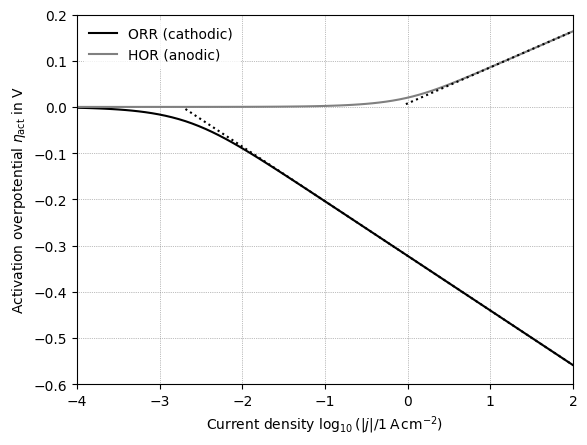

In [46]:
from phdtools.plots.fuel_cell import plot_tafel_plot

fig = plot_tafel_plot(
    fname_bv_hor=DataID(DataType.FIGURE, Chapter.METHODS, 15).get_path(
        fail_exists=False
    )
    / f"{FILE_DATE}_butler_volmer_hor_model.csv",
    fname_tf_hor=DataID(DataType.FIGURE, Chapter.METHODS, 15).get_path(
        fail_exists=False
    )
    / f"{FILE_DATE}_tafel_hor_model.csv",
    fname_bv_orr=DataID(DataType.FIGURE, Chapter.METHODS, 15).get_path(
        fail_exists=False
    )
    / f"{FILE_DATE}_butler_volmer_orr_model.csv",
    fname_tf_orr=DataID(DataType.FIGURE, Chapter.METHODS, 15).get_path(
        fail_exists=False
    )
    / f"{FILE_DATE}_tafel_orr_model.csv",
)

#### Activation overpotential vs. temperature
[back](#Table-of-contents)

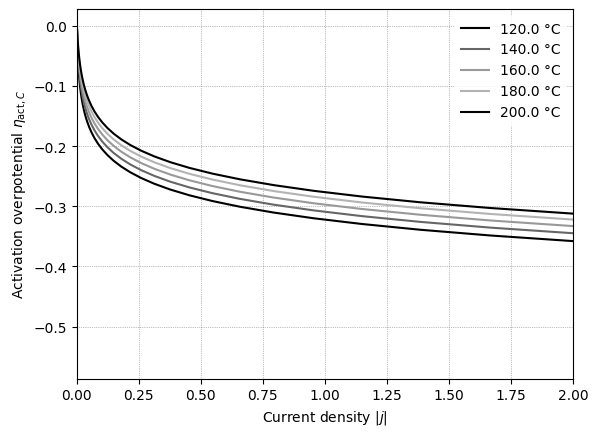

In [47]:
from phdtools.plots.fuel_cell import plot_activation_overpotential

fig = plot_activation_overpotential(
    fname=DataID(DataType.FIGURE, Chapter.METHODS, 15).get_path(fail_exists=False)
    / f"{FILE_DATE}_butler_volmer_orr_model.csv",
    branch="cathodic",
)

### Internal resistance
[back](#Table-of-contents)

Charge transport (of ions and electrons) is driven by electrical driving forces, i.e. a voltage gradient, and chemical driving forces, i.e. a concentration gradient (only ions). 
Generally, the electrical driving forces dominate charge transport, so chemical driving forces can be neglected, such that $\CurrentDensity$ can be related to the voltage gradient as 
$$
\newcommand{\Conductivity}{\sigma}
\newcommand{\OhmicLosses}{\eta_\mathrm{ohmic}}
\newcommand{\Voltage}{V}
\newcommand{\ConductorLength}{L}
\newcommand{\Current}{i}
\newcommand{\CrossSectionalArea}{A}
\newcommand{\Resistance}{R}
\newcommand{\AreaSpecificResistance}{R_s}
%
\CurrentDensity = \Conductivity \frac{\mathrm{d}\Voltage}{\mathrm{d}x}
$$
where $\Conductivity$ is the conductivity of the conductor and $\mathrm{d}\Voltage/\mathrm{d}x$ is the voltage gradient driving charge transport along the conductor. 
If we assume the conductor to be uniform with constant cross-sectional area $\CrossSectionalArea$ we can write $\mathrm{d}\Voltage/\mathrm{d}x = \Voltage/\ConductorLength$ and rearrange for $\Voltage$ we yield
$$
\Voltage 
    = \CurrentDensity \left(\frac{\ConductorLength}{\Conductivity}\right) 
    = \Current \underbrace{\left(\frac{\ConductorLength}{\Conductivity\CrossSectionalArea}\right)}_{\coloneqq \Resistance}
$$
where charge flux $\CurrentDensity$ was substituted with current using the relation $\Current = \CrossSectionalArea \CurrentDensity$. 
This relation is known as Ohm's Law, hence the losses are referred to as *ohmic losses* $\OhmicLosses$. 

#### Temperature dependence of the electrolyte conductivity
[back](#Table-of-contents)

In [48]:
from phdtools.models.zhang_2007 import conductivityModel

# request_free_id(DataType.FIGURE, Chapter.UNUSED)

In [49]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 17)


@auto_create_path
def save_conductivity_values(path):
    fname = path / f"{TODAY}_conductivity_vs_temperature.csv"

    temperatureRangeSI = np.linspace(120, 200) + 273.15
    conductivityValuesSI = conductivityModel(params, temperatureRangeSI)

    description = (
        f"Temperature dependence of the conductivity of the electrolyte.\n"
        f"Conductivity is modelled after Zhang, Jianlu et al. (2007).\n"
        f"\n"
        f"References: \n"
        f"----------- \n"
        f"Zhang, Jianlu et al. (2007) “Polybenzimidazole-membrane-based PEM fuel cell\n"
        f"  in the temperature range of 120–200 °C,” Journal of Power Sources, 172(1),\n"
        f"  pp. 163–171. Available at: https://doi.org/10.1016/j.jpowsour.2007.07.047."
    )

    with open(fname, "w+") as f:
        write_metadata(f, description)
        np.savetxt(
            f,
            np.c_[temperatureRangeSI, conductivityValuesSI * 1e-2],
            header='"T(K)","s(S/cm)"',
            delimiter=",",
            comments="",
            fmt=["%.2f", "%.18e"],
        )


save_conductivity_values(
    data_id,
    doc=r"Temperature dependence of the electrolyte conductivity for a \gls{PA-PBI} membrane modelled after \textcite{Zhang.2007b}",
    overwrite=overwrite,
)

In [50]:
!ls {DataID(DataType.FIGURE, Chapter.UNUSED, 17).get_path(fail_exists=False)}

260407_conductivity_vs_temperature.csv


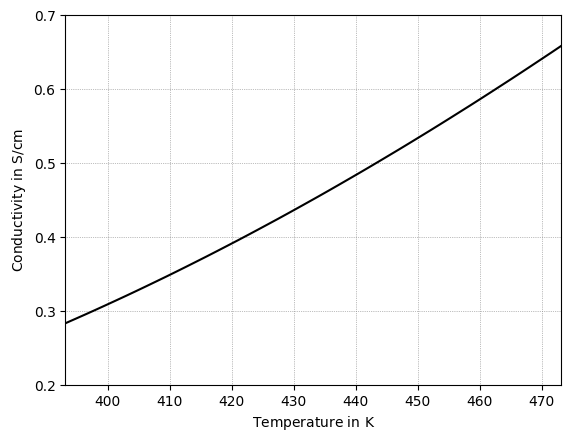

In [51]:
from phdtools.plots.fuel_cell import plot_conductivity_vs_temperature

fig = plot_conductivity_vs_temperature(
    fname=DataID(DataType.FIGURE, Chapter.UNUSED, 17).get_path(fail_exists=False)
    / f"{FILE_DATE}_conductivity_vs_temperature.csv",
)

#### Area-specific resistance
[back](#Table-of-contents)

In [52]:
from phdtools.models.zhang_2007 import MEMBRANE_THICKNESS_SI

To account for size differences, usually area-normalized resistances are reported. 
The *area-specific resistance* $\AreaSpecificResistance$ is defined as
$$
\AreaSpecificResistance = \CrossSectionalArea \Resistance = \frac{\ConductorLength}{\Conductivity}
$$
such that 
$$
\OhmicLosses = \AreaSpecificResistance \CurrentDensity
$$

In [53]:
for temperatureCelsius in [120, 160, 200]:
    display(
        Latex(
            r"$R_s = {:.4f}\,\mathrm{{\Omega\,cm^2}}$ at $T = {}\,\mathrm{{\degree C}}$".format(
                (
                    MEMBRANE_THICKNESS_SI
                    / conductivityModel(params, temperatureCelsius + 273.15)[0]
                )
                * 1e4,
                temperatureCelsius,
            )
        )
    )

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

#### Internal resistance vs. temperature
[back](#Table-of-contents)

In [54]:
# request_free_id(DataType.FIGURE, Chapter.UNUSED)

In [55]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 18)


@auto_create_path
def save_internal_resistance_values(path):
    fname = path / f"{TODAY}_internal_resistance_vs_temperature.csv"

    temperatureRangeSI = np.array([120, 140, 160, 180, 200]) + 273.15
    currentDensityRangeSI = (
        np.linspace(0, 2) * 1e4
    )  # A/cm2 = A / (1e-2 m)2 = A / (1e-4 m2)

    ohmicLossesValuesSI = np.zeros(
        (len(temperatureRangeSI), len(currentDensityRangeSI))
    )
    ohmicLossesValuesSI[:] = np.nan

    for num, temperatureKelvin in enumerate(temperatureRangeSI):
        areaSpecificResistanceSI = MEMBRANE_THICKNESS_SI / conductivityModel(
            params, temperatureKelvin
        )

        ohmicLossesValuesSI[num] = areaSpecificResistanceSI * currentDensityRangeSI

    description = (
        f"Temperature dependence of the electrolyte resistance j * Rs (in V),\n"
        f"where Rs = = t/s. Columns refer to different temperature values\n"
        f"given in deg. C. Conductivity s is modelled after Zhang, Jianlu et al. (2007)\n"
        f"Membrane thickness t was estimate to align with the area-specific resistances\n"
        f"reported in their original paper as \n"
        f"   t = {MEMBRANE_THICKNESS_SI*1e-3:.4g} mm\n"
        f"\n"
        f"References: \n"
        f"----------- \n"
        f"Zhang, Jianlu et al. (2007) “Polybenzimidazole-membrane-based PEM fuel cell\n"
        f"  in the temperature range of 120–200 °C,” Journal of Power Sources, 172(1),\n"
        f"  pp. 163–171. Available at: https://doi.org/10.1016/j.jpowsour.2007.07.047."
    )

    with open(fname, "w+") as f:
        write_metadata(f, description)
        np.savetxt(
            f,
            np.c_[currentDensityRangeSI * 1e-4, ohmicLossesValuesSI.T],
            header='"j(A/cm2)",'
            + ",".join(
                f"{temperatureKelvin-273.15:.0f}"
                for temperatureKelvin in temperatureRangeSI
            ),
            delimiter=",",
            comments="",
        )


save_internal_resistance_values(
    data_id,
    doc=r"Temperature dependence of the electrolyte resistance for a \gls{PA-PBI} membrane modelled after \textcite{Zhang.2007b}",
    overwrite=overwrite,
)

In [56]:
!ls {DataID(DataType.FIGURE, Chapter.UNUSED, 18).get_path(fail_exists=False)}

260407_internal_resistance_vs_temperature.csv


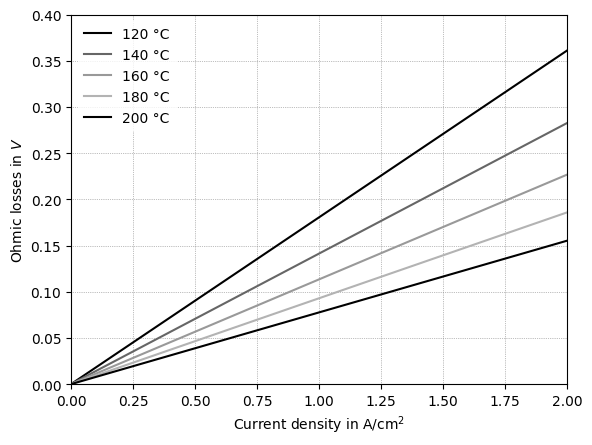

In [57]:
from phdtools.plots.fuel_cell import plot_internal_resistance_vs_temperature

fig = plot_internal_resistance_vs_temperature(
    fname=DataID(DataType.FIGURE, Chapter.UNUSED, 18).get_path(fail_exists=False)
    / f"{FILE_DATE}_internal_resistance_vs_temperature.csv",
)

### Mass transport limitations
[back](#Table-of-contents)

The bulk concentration of reactants $\Concentration{R}{0}$ is higher than catalyst layer concentration of reactants $\Concentration{R}{\ast}$, resulting in an approximately linear concentration gradient over the gas diffusion layer. 
Similarly, bluk concentration of products $\Concentration{P}{0}$ is lower than catalyst layer concentration of products $\Concentration{P}{\ast}$. 
Reactant depletion and product accumulation results in two kinds of losses:
1. *Nerstian losses*: Reversible fuel cell voltage decreases as predicted by the Nernst equation. 
2. *Reaction losses*: Activation (reaction rate) losses increase as predicted by the Butler-Volmer equation. 

#### Maxwell-Stefan diffusion
[back](#Table-of-contents)

$$
\newcommand{\dd}{\mathrm{d}}
\newcommand{\BasisVector}[1]{\vec{e}_{#1}}
\newcommand{\MoleFraction}[1]{x_{#1}}
\newcommand{\MolarDensity}{c}
\newcommand{\CombinedMolarFlux}[1]{\vec{N}_{#1}}
\newcommand{\Pressure}{p}
\newcommand{\EffectiveDiffusionCoef}[1]{D^\mathrm{eff}_{#1}}
\newcommand{\DiffusionCoef}[1]{D_{#1}}
$$
Mass transport through the prous gas diffusion layer may be described by the *Stefan-Maxwell equations*: 
$$
\nabla \MoleFraction{k} = - \sum_{j = 1}^{n} \frac{1}{\MolarDensity \EffectiveDiffusionCoef{kj}} \left(\MoleFraction{j}\CombinedMolarFlux{k} - \MoleFraction{k}\CombinedMolarFlux{j}\right)
$$
where $\MolarDensity$ denotes the molar density of the $n$-component mixture, $\MoleFraction{i}$ and $\CombinedMolarFlux{i}$ denote the mole fractions and *combined* molar flux of species $i$, and $\DiffusionCoef{ij}$ is used to denote the *effective* binary diffusivity for a pair of species $i$ and $j$. 

##### Binary and effective binary diffusivity
[back](#Table-of-contents)

In [58]:
from phdtools.data.diffusion import pressureDiffusivityProductModel

The effective diffusivity $\EffectiveDiffusionCoef{ij}$ in a porous structure is related to the binary diffusivity $\DiffusionCoef{ij}$ via the Bruggemann correction, see (O’Hayre, 2016)
$$
\newcommand{\VoidFraction}{\varepsilon}
\EffectiveDiffusionCoef{ij} = \VoidFraction^{1.5}
$$
where $\VoidFraction$ is the void fraction of the porous structure and $1.5$ is an empirical constant that depends on the geometry of the porous structure. 
The binary diffusion coefficients $\DiffusionCoef{ij}$ are modelled after Slattery and Bird (1958). 
The void fraction is estimated at $\VoidFraction \approx 0.4$ (O’Hayre, 2016, p. 173). 

In [59]:
from phdtools.models.ohayre_2016 import ELECTRODE_POROSITY

temperatureKelvin = FUEL_CELL_TEMPERATURE_SI
pressureSI = ISO_STD_REF_PRESSURE_SI

diffusivitySI = (
    pressureDiffusivityProductModel(
        Compound["N2(ref)"], Compound["O2(ref)"], temperatureKelvin
    )
    / pressureSI
)
effectiveDiffusivitySI = diffusivitySI * ELECTRODE_POROSITY**1.5

display(
    Latex(
        r"At $T = {}\,^\circ\mathrm{{C}}$ and $p = {}\,\mathrm{{bar}}$:".format(
            temperatureKelvin - 273.15, pressureSI * 1e-5
        )
    ),
    Latex(
        r"$D_\mathrm{{N_2,O_2}} = {:.4f} \,\mathrm{{cm^2/s}}$".format(
            diffusivitySI[0] * 1e4
        )
    ),
    Latex(
        r"$D^\mathrm{{eff}}_\mathrm{{N_2,O_2}} = {:.4f} \,\mathrm{{cm^2/s}}$".format(
            effectiveDiffusivitySI[0] * 1e4
        )
    ),
)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

##### 1D diffusion model
[back](#Table-of-contents)

For one-dimensional diffusion normal to the (geometric) electrode surface ($z$-direction), the Stefan-Maxwell equations become 
$$
\frac{\dd\MoleFraction{k}}{\dd z} 
    = - \frac{1}{\MolarDensity{}} 
    \sum_{j = 1}^{n} \frac{1}{\EffectiveDiffusionCoef{kj}} \left[\MoleFraction{j} \left(\CombinedMolarFlux{k} \cdot \BasisVector{z}\right) - \MoleFraction{k} \left(\CombinedMolarFlux{j} \cdot \BasisVector{z}\right)\right]
$$
where for the *cathode*, the combined molar flux normal to the geometric surface are given by
$$
\CombinedMolarFlux{j} \cdot \BasisVector{z} =
\begin{cases}
    0 \quad &\text{for} \quad j = \ce{N2}\\
    \CurrentDensity{} / \left(4 \FaradayConst{}\right) \quad &\text{for} \quad j = \ce{O2}\\
    - \CurrentDensity{} / \left(2 \FaradayConst{}\right) \quad &\text{for} \quad j = \ce{H2O(g)}\\
\end{cases}
$$
and, similarly, for the *anode*
$$
\CombinedMolarFlux{j} \cdot \BasisVector{z} =
\begin{cases}
    \CurrentDensity{} / \left(2 \FaradayConst{}\right) \quad &\text{for} \quad j = \ce{H2}\\
    0 \quad &\text{for} \quad j \in \{\ce{CH4}, \ce{CO}, \ce{CO2}, \ce{H2O(g)}\}\\
\end{cases}
$$


For a perfect gas
$$
\frac{1}{\MolarDensity} = \frac{\GasConst\Temperature{}}{\Pressure{}}
$$

###### Cathode gas diffusion layer
[back](#Table-of-contents)

$$\newcommand{\DiffusionLayerThickness}{\delta}$$
With $z_{+} := z/\DiffusionLayerThickness \implies \dd / \dd{z} = (\partial{z_{+}}/\partial{z}) \, \dd / \dd{z_{+}} = \DiffusionLayerThickness^{-1} \dd / \dd{z_{+}}$ 
$$
\begin{align}
    \frac{\dd\MoleFraction{\ce{N2}}}{\dd z_{+}} 
        &= A_1 \CurrentDensity{} \, \MoleFraction{\ce{N2}} \\
    \frac{\dd\MoleFraction{\ce{O2}}}{\dd z_+} 
        &= A_2 \CurrentDensity{} \MoleFraction{\ce{N2}} + A_3 \CurrentDensity{} (\MoleFraction{\ce{O2}} + 1) \\
    A_1 &= \frac{1}{\MolarDensity} \left[
            \frac{1}{\DiffusionCoef{\ce{N2},\ce{O2}}} 
            - 2 \frac{1}{\DiffusionCoef{\ce{N2},\ce{H2O(g)}}} 
        \right] \frac{\DiffusionLayerThickness{}}{4\FaradayConst{}} \\
    A_2 & = \frac{1}{\MolarDensity} \left[
            \frac{1}{\DiffusionCoef{\ce{O2},\ce{H2O(g)}}} 
            - \frac{1}{\DiffusionCoef{\ce{O2},\ce{N2}}} 
        \right] \frac{\DiffusionLayerThickness{}}{4\FaradayConst{}} \\
    A_3 & = -\frac{1}{\MolarDensity} 
            \frac{1}{\DiffusionCoef{\ce{O2},\ce{H2O(g)}}} 
            \frac{\DiffusionLayerThickness{}}{4\FaradayConst{}}
\end{align}
$$

Integrating yields
$$
\MoleFraction{\ce{N2}}(z_+) = 
    \MoleFraction{\ce{N2},0} \exp\left\{A_1 \CurrentDensity{} z_+ \right\} 
$$
and 
$$
\MoleFraction{\ce{O2}}(z_+) = 
    \frac{A_2}{A_1 - A_3} \MoleFraction{\ce{N2},0} \exp\left\{A_1 \CurrentDensity{} z_+ \right\} 
    + \left[1 + \MoleFraction{\ce{O2},0} - \frac{A_2}{A_1 - A_3} \MoleFraction{\ce{N2},0} \right] \exp\left\{A_3 \CurrentDensity{} z_+ \right\} 
    - 1
$$

In [60]:
from phdtools.models.meck_2025 import (
    diffusionModelCathode,
    DIFFUSION_LAYER_THICKNESS_SI,
)

In [61]:
coordinateRange = np.linspace(0, 1)

temperatureKelvin = FUEL_CELL_TEMPERATURE_SI
pressureBar = ISO_STD_REF_PRESSURE_SI * 1e-5
currentDensitySI = 2e4

moleFractionsAnalytical = diffusionModelCathode(
    currentDensitySI=currentDensitySI,
    moleFractionIn=moleFractionCathodeIn,
    temperatureKelvin=temperatureKelvin,
    pressureBar=pressureBar,
    coordinate=coordinateRange,
    method="analytical",
)

moleFractionsNumerical = diffusionModelCathode(
    currentDensitySI=currentDensitySI,
    moleFractionIn=moleFractionCathodeIn,
    temperatureKelvin=temperatureKelvin,
    pressureBar=pressureBar,
    coordinate=coordinateRange,
    method="numerical",
)

assert np.isclose(moleFractionsAnalytical, moleFractionsNumerical).all()

In [62]:
# request_free_id(DataType.FIGURE, Chapter.UNUSED)

In [63]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 19)


@auto_create_path
def save_mole_fractions_gdl_cathode(path):

    fname = path / f"{TODAY}_mole_fractions_gdl_cathode.csv"

    temperatureKelvin = FUEL_CELL_TEMPERATURE_SI
    pressureBar = ISO_STD_REF_PRESSURE_SI * 1e-5
    currentDensitySI = 2e4

    coordinateRange = np.linspace(0, 1)

    moleFractionCathodeIn = np.zeros(len(Compound))

    moleFractionCathodeIn[Compound["H2O1(g)"].value] = (
        vapourPressureModel(ISO_STD_REF_TEMPERATURE_SI)[0]
        * 1e-5
        * ISO_STD_REF_REL_HUMIDITY
    ) / pressureBar

    for c in Compound:
        if c.name != "H2O1(g)":
            moleFractionCathodeIn[c.value] = dryMoleFractionAir[c.value] * (
                1 - moleFractionCathodeIn[Compound["H2O1(g)"].value]
            )

    moleFraction = diffusionModelCathode(
        currentDensitySI=currentDensitySI,
        moleFractionIn=moleFractionCathodeIn,
        temperatureKelvin=temperatureKelvin,
        pressureBar=pressureBar,
        coordinate=coordinateRange,
        method="analytical",
    )

    diffusivitySI = np.full((len(Compound), len(Compound)), np.nan)

    for c1 in Compound:
        for c2 in Compound:
            diffusivitySI[c1.value, c2.value] = diffusivitySI[c2.value, c1.value] = (
                pressureDiffusivityProductModel(c1, c2, temperatureKelvin)[0]
                / (1e5 * pressureBar)
            )

    description = (
        f"1D Stefan-Maxwell diffusion in the cathode gas diffusion layer \n"
        f"normal to the (geometric) electrode surface (z-direction).\n"
        f"Binary diffusivities D[ij] were computed follwing Slattery and Bird (1958)\n"
        f"and corrected using the Bruggemann correction Deff[ij] = D[ij] e^1.5 \n"
        f"using values for the critical points from Linstrom (1997). \n"
        f"The void fraction e was estimate at {ELECTRODE_POROSITY} (O’Hayre, 2016, p.173).\n"
        f"The diffusion layer thickness t was estimate at {DIFFUSION_LAYER_THICKNESS_SI*1e6:.4f} µm.\n"
        f"The values in the columns are for the mole fraction at: \n"
        f"    j = {currentDensitySI * 1e-4:.2f} A/cm2\n"
        f"    T = {temperatureKelvin - 273.15:.2f} C\n"
        f"    p = {pressureBar} bar\n"
        f"The z-coordinate is normalized with the diffusion layer\n"
        f"thickness t, i.e. z+ := z / t. "
        f"The diffusivity values are:\n"
        f"    D[N2(ref),O2(ref)] = {diffusivitySI[Compound["N2(ref)"].value, Compound["O2(ref)"].value]*1e4:.4g} cm2/s\n"
        f"    D[N2(ref),H2O1(g)] = {diffusivitySI[Compound["N2(ref)"].value, Compound["H2O1(g)"].value]*1e4:.4g} cm2/s\n"
        f"    D[O2(ref),N2(ref)] = {diffusivitySI[Compound["O2(ref)"].value, Compound["N2(ref)"].value]*1e4:.4g} cm2/s\n"
        f"    D[O2(ref),H2O1(g)] = {diffusivitySI[Compound["O2(ref)"].value, Compound["H2O1(g)"].value]*1e4:.4g} cm2/s\n"
        f"\n"
        f"References: \n"
        f"----------- \n"
        f"Linstrom, P. (1997) “NIST Chemistry WebBook, NIST Standard Reference”\n"
        f"   Database 69.National Institute of Standards and Technology \n"
        f"   Available at: https://doi.org/10.18434/T4D303. \n"
        f"\n"
        f"O’Hayre, R.P. (2016) Fuel cell fundamentals. Third edition. \n"
        f"   John Wiley & Sons. Available at: https://doi.org/10.1002/9781119191766.\n"
        f"\n"
        f"Slattery, J.C. and Bird, R.B. (1958) “Calculation of the diffusion coef-\n"
        f"  ficient of dilute gases and of the self‐diffusion coefficient of dense\n"
        f"  gases,” AIChE Journal, 4(2), pp. 137–142. Available at: \n"
        f"  https://doi.org/10.1002/aic.690040205.\n"
        f"\n"
        f"Zhang, Jianlu et al. (2007) “Polybenzimidazole-membrane-based PEM fuel cell\n"
        f"  in the temperature range of 120–200 °C,” Journal of Power Sources, 172(1),\n"
        f"  pp. 163–171. Available at: https://doi.org/10.1016/j.jpowsour.2007.07.047.\n"
    )

    with open(fname, "w+") as f:
        write_metadata(f, description)
        np.savetxt(
            f,
            np.c_[coordinateRange, moleFraction[:, :, 0].T],
            header="z+," + ",".join(f"{c.name}" for c in Compound),
            delimiter=",",
            comments="",
        )


save_mole_fractions_gdl_cathode(
    data_id,
    doc=(
        r"Diffusion profile across the cathode gas diffusion layer determined from the 1D Stefan-Maxwell diffusion model "
        r"described in \cref{sec:methods-case-study-fuel-cell}"
    ),
    overwrite=overwrite,
)

In [64]:
!ls {DataID(DataType.FIGURE, Chapter.UNUSED, 19).get_path(fail_exists=False)}

260407_mole_fractions_gdl_cathode.csv


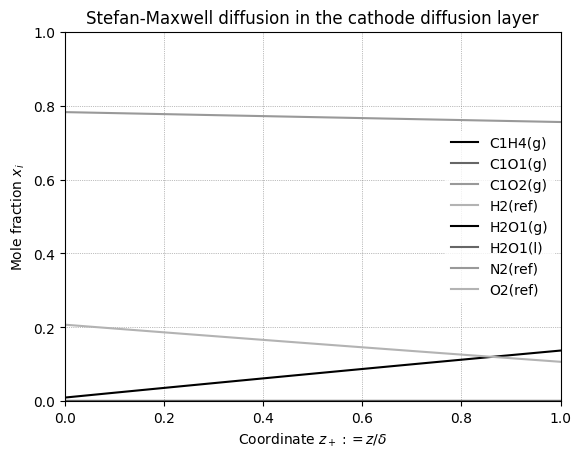

In [65]:
from phdtools.plots.fuel_cell import plot_mole_fractions_gdl

fig = plot_mole_fractions_gdl(
    fname=DataID(DataType.FIGURE, Chapter.UNUSED, 19).get_path(fail_exists=False)
    / f"{FILE_DATE}_mole_fractions_gdl_cathode.csv"
)
_ = fig.gca().set_title("Stefan-Maxwell diffusion in the cathode diffusion layer")

###### Anode gas diffusion layer
[back](#Table-of-contents)

Assuming the anode is fed with reformate 
$$
\begin{align}
    \frac{\dd\MoleFraction{i}}{\dd z_{+}} 
        &= B_i \CurrentDensity{} \, \MoleFraction{\ce{i}} \quad i \in \{\ce{CH4}, \ce{CO}, \ce{CO2}, \ce{H2O(g)}\}\\
    B_i &= \frac{1}{\MolarDensity} 
            \frac{1}{\DiffusionCoef{i,\ce{H2}}} 
            \frac{\DiffusionLayerThickness{}}{4\FaradayConst{}}
\end{align}
$$

Integrating yields
$$
\MoleFraction{i}(z_+) = 
    \MoleFraction{i,0} \exp\left\{B_i \CurrentDensity{} z_+ \right\} 
$$
and 
$$
\MoleFraction{\ce{H2}}(z_+) = 
    1 - \sum_{j \neq \ce{H2}} \MoleFraction{j}(z_+)
$$

In [66]:
from phdtools.models.meck_2025 import diffusionModelAnode

In [67]:
coordinateRange = np.linspace(0, 1)

temperatureKelvin = FUEL_CELL_TEMPERATURE_SI
pressureBar = ISO_STD_REF_PRESSURE_SI * 1e-5
currentDensitySI = 2e4

moleFractionAnodeIn = np.zeros(len(Compound))
moleFractionAnodeIn[Compound["C1H4(g)"].value] = 0.03
moleFractionAnodeIn[Compound["C1O1(g)"].value] = 0.09
moleFractionAnodeIn[Compound["C1O2(g)"].value] = 0.08
moleFractionAnodeIn[Compound["H2(ref)"].value] = 0.45
moleFractionAnodeIn[Compound["H2O1(g)"].value] = 0.35

moleFractionsAnalytical = diffusionModelAnode(
    currentDensitySI=currentDensitySI,
    moleFractionIn=moleFractionAnodeIn,
    temperatureKelvin=temperatureKelvin,
    pressureBar=pressureBar,
    coordinate=coordinateRange,
    method="analytical",
)

moleFractionsNumerical = diffusionModelAnode(
    currentDensitySI=currentDensitySI,
    moleFractionIn=moleFractionAnodeIn,
    temperatureKelvin=temperatureKelvin,
    pressureBar=pressureBar,
    coordinate=coordinateRange,
    method="numerical",
)

assert np.isclose(moleFractionsAnalytical, moleFractionsNumerical).all()

In [68]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 20)


@auto_create_path
def save_mole_fractions_gdl_anode(path):

    fname = path / f"{TODAY}_mole_fractions_gdl_anode.csv"

    temperatureKelvin = FUEL_CELL_TEMPERATURE_SI
    pressureBar = ISO_STD_REF_PRESSURE_SI * 1e-5
    currentDensitySI = 2e4

    moleFractionAnodeIn = np.zeros(len(Compound))
    moleFractionAnodeIn[Compound["C1H4(g)"].value] = 0.03
    moleFractionAnodeIn[Compound["C1O1(g)"].value] = 0.09
    moleFractionAnodeIn[Compound["C1O2(g)"].value] = 0.08
    moleFractionAnodeIn[Compound["H2(ref)"].value] = 0.45
    moleFractionAnodeIn[Compound["H2O1(g)"].value] = 0.35

    coordinateRange = np.linspace(0, 1)

    moleFraction = diffusionModelAnode(
        currentDensitySI=currentDensitySI,
        moleFractionIn=moleFractionAnodeIn,
        temperatureKelvin=temperatureKelvin,
        pressureBar=pressureBar,
        coordinate=coordinateRange,
        method="analytical",
    )

    diffusivitySI = np.full((len(Compound), len(Compound)), np.nan)

    for c1 in Compound:
        for c2 in Compound:
            diffusivitySI[c1.value, c2.value] = diffusivitySI[c2.value, c1.value] = (
                pressureDiffusivityProductModel(c1, c2, temperatureKelvin)[0]
                / (1e5 * pressureBar)
            )

    description = (
        f"1D Stefan-Maxwell diffusion in the anode gas diffusion layer \n"
        f"normal to the (geometric) electrode surface (z-direction).\n"
        f"Binary diffusivities D[ij] were computed follwing Slattery and Bird (1958)\n"
        f"and corrected using the Bruggemann correction Deff[ij] = D[ij] e^1.5 \n"
        f"using values for the critical points from Linstrom (1997). \n"
        f"The void fraction e was estimate at {ELECTRODE_POROSITY} (O’Hayre, 2016, p.173).\n"
        f"The diffusion layer thickness t was estimate at {DIFFUSION_LAYER_THICKNESS_SI*1e6:.4f} µm.\n"
        f"The values in the columns are for the mole fraction at: \n"
        f"    j = {currentDensitySI * 1e-4:.2f} A/cm2\n"
        f"    T = {temperatureKelvin - 273.15:.2f} C\n"
        f"    p = {pressureBar} bar\n"
        f"The z-coordinate is normalized with the diffusion layer\n"
        f"thickness t, i.e. z+ := z / t. "
        f"The diffusivity values are:\n"
        f"    D[C1H4(g),H2(ref)] = {diffusivitySI[Compound["C1H4(g)"].value, Compound["H2(ref)"].value]*1e4:.4g} cm2/s\n"
        f"    D[C1O1(g),H2(ref)] = {diffusivitySI[Compound["C1O1(g)"].value, Compound["H2(ref)"].value]*1e4:.4g} cm2/s\n"
        f"    D[C1O2(g),H2(ref)] = {diffusivitySI[Compound["C1O2(g)"].value, Compound["H2(ref)"].value]*1e4:.4g} cm2/s\n"
        f"    D[H2O1(g),H2(ref)] = {diffusivitySI[Compound["H2O1(g)"].value, Compound["H2(ref)"].value]*1e4:.4g} cm2/s\n"
        f"\n"
        f"References: \n"
        f"----------- \n"
        f"Linstrom, P. (1997) “NIST Chemistry WebBook, NIST Standard Reference”\n"
        f"   Database 69.National Institute of Standards and Technology \n"
        f"   Available at: https://doi.org/10.18434/T4D303. \n"
        f"\n"
        f"O’Hayre, R.P. (2016) Fuel cell fundamentals. Third edition. \n"
        f"   John Wiley & Sons. Available at: https://doi.org/10.1002/9781119191766.\n"
        f"\n"
        f"Slattery, J.C. and Bird, R.B. (1958) “Calculation of the diffusion coef-\n"
        f"  ficient of dilute gases and of the self‐diffusion coefficient of dense\n"
        f"  gases,” AIChE Journal, 4(2), pp. 137–142. Available at: \n"
        f"  https://doi.org/10.1002/aic.690040205.\n"
        f"\n"
        f"Zhang, Jianlu et al. (2007) “Polybenzimidazole-membrane-based PEM fuel cell\n"
        f"  in the temperature range of 120–200 °C,” Journal of Power Sources, 172(1),\n"
        f"  pp. 163–171. Available at: https://doi.org/10.1016/j.jpowsour.2007.07.047.\n"
    )

    with open(fname, "w+") as f:
        write_metadata(f, description)
        np.savetxt(
            f,
            np.c_[coordinateRange, moleFraction[:, :, 0].T],
            header="z+," + ",".join(f"{c.name}" for c in Compound),
            delimiter=",",
            comments="",
        )


save_mole_fractions_gdl_anode(
    data_id,
    doc=(
        r"Diffusion profile across the anode gas diffusion layer determined from the 1D Stefan-Maxwell diffusion model "
        r"described in \cref{sec:methods-case-study-fuel-cell}"
    ),
    overwrite=overwrite,
)

In [69]:
!ls {DataID(DataType.FIGURE, Chapter.UNUSED, 20).get_path(fail_exists=False)}

260407_mole_fractions_gdl_anode.csv


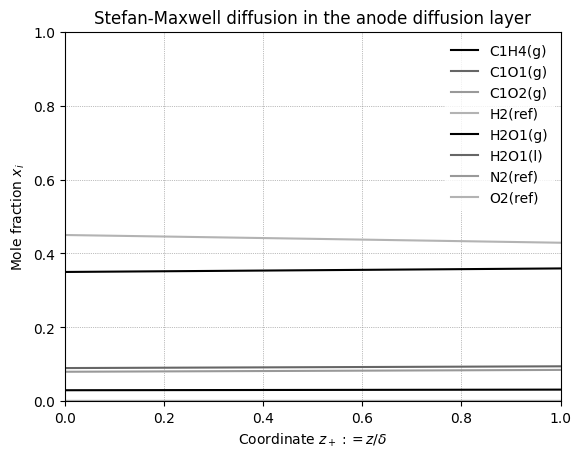

In [70]:
from phdtools.plots.fuel_cell import plot_mole_fractions_gdl

fig = plot_mole_fractions_gdl(
    fname=DataID(DataType.FIGURE, Chapter.UNUSED, 20).get_path(fail_exists=False)
    / f"{FILE_DATE}_mole_fractions_gdl_anode.csv"
)
_ = fig.gca().set_title("Stefan-Maxwell diffusion in the anode diffusion layer")

#### Limiting current density
[back](#Table-of-contents)

The limiting case for mass transport within the gas diffusion layer is given by the case where reactant concentration in the catalyst layer falls to $\Concentration{R}{\ast} = 0$. 
Then the diffusion flux $\CombinedMolarFlux{R}$ assumes its maximum value. 
Since diffusion flux is related to current density (charge flux) via $\CurrentDensity = \StoichiometricNumber{R} \FaradayConst \CombinedMolarFlux{R}$
a limiting current density $\newcommand{\LimitingCurrentDensity}{j_L}\LimitingCurrentDensity$ can be defined. 

In [71]:
data_id = DataID(DataType.FIGURE, Chapter.METHODS, 16)


@auto_create_path
def save_interface_mole_fractions(path):

    temperatureRangeSI = np.array([120, 140, 160, 180, 200]) + 273.15

    pressureBar = ISO_STD_REF_PRESSURE_SI * 1e-5
    currentDensityRangeSI = np.linspace(0, 5) * 1e4

    moleFractionCathodeIn = np.zeros(len(Compound))
    moleFractionCathodeIn[Compound["H2O1(g)"].value] = (
        vapourPressureModel(ISO_STD_REF_TEMPERATURE_SI)[0]
        * 1e-5
        * ISO_STD_REF_REL_HUMIDITY
    ) / pressureBar
    for c in Compound:
        if c.name != "H2O1(g)":
            moleFractionCathodeIn[c.value] = dryMoleFractionAir[c.value] * (
                1 - moleFractionCathodeIn[Compound["H2O1(g)"].value]
            )

    moleFractionOxygenInterface = np.full(
        (len(temperatureRangeSI), len(currentDensityRangeSI)), np.nan
    )
    moleFractionHydrogenInterface = np.full(
        (len(temperatureRangeSI), len(currentDensityRangeSI)), np.nan
    )

    moleFractionAnodeIn = np.zeros(len(Compound))
    moleFractionAnodeIn[Compound["C1H4(g)"].value] = 0.03
    moleFractionAnodeIn[Compound["C1O1(g)"].value] = 0.09
    moleFractionAnodeIn[Compound["C1O2(g)"].value] = 0.08
    moleFractionAnodeIn[Compound["H2(ref)"].value] = 0.45
    moleFractionAnodeIn[Compound["H2O1(g)"].value] = 0.35

    for num, temperatureKelvin in enumerate(temperatureRangeSI):

        moleFractionAnode = diffusionModelAnode(
            currentDensitySI=currentDensityRangeSI,
            moleFractionIn=moleFractionAnodeIn,
            temperatureKelvin=temperatureKelvin,
            pressureBar=pressureBar,
            coordinate=1,
            method="analytical",
        )

        moleFractionCathode = diffusionModelCathode(
            currentDensitySI=currentDensityRangeSI,
            moleFractionIn=moleFractionCathodeIn,
            temperatureKelvin=temperatureKelvin,
            pressureBar=pressureBar,
            coordinate=1,
            method="analytical",
        )

        moleFractionHydrogenInterface[num] = (
            moleFractionAnode[Compound["H2(ref)"].value, 0, :]
            / moleFractionAnodeIn[Compound["H2(ref)"].value]
        )
        moleFractionOxygenInterface[num] = (
            moleFractionCathode[Compound["O2(ref)"].value, 0, :]
            / moleFractionCathodeIn[Compound["O2(ref)"].value]
        )

        description = (
            f"Mole fractions at the interface between anode diffusion layer and electrolyte\n"
            f"film for different values of temperature T (columns) and current density j.\n"
            f"The values for the mole fraction are normalized with the bulk mole fraction\n"
            f"x_H2,0. "
            f"(x_CH4,0 = {moleFractionAnodeIn[Compound["C1H4(g)"].value]:.4f}, "
            f"x_CO,0 = {moleFractionAnodeIn[Compound["C1O1(g)"].value]:.4f}, "
            f"x_CO2,0 = {moleFractionAnodeIn[Compound["C1O2(g)"].value]:.4f}, \n"
            f"x_H2,0 = {moleFractionAnodeIn[Compound["H2(ref)"].value]:.4f}, "
            f"x_H2O,0 = {moleFractionAnodeIn[Compound["H2O1(g)"].value]:.4f}).\n"
            f"The values are obtained by solving a 1D Stefan-Maxwell diffusion model \n"
            f"normal to the (geometric) electrode surface (z-direction).\n"
            f"Binary diffusivities D[ij] were computed follwing Slattery and Bird (1958)\n"
            f"and corrected using the Bruggemann correction Deff[ij] = D[ij] e^1.5 \n"
            f"using values for the critical points from Linstrom (1997). \n"
            f"The void fraction e was estimated at {ELECTRODE_POROSITY} (O’Hayre, 2016, p.173).\n"
            f"The diffusion layer thickness t was estimate at {DIFFUSION_LAYER_THICKNESS_SI*1e6:.4f} µm.\n"
            f"\n"
            f"References: \n"
            f"----------- \n"
            f"Linstrom, P. (1997) “NIST Chemistry WebBook, NIST Standard Reference”\n"
            f"   Database 69.National Institute of Standards and Technology \n"
            f"   Available at: https://doi.org/10.18434/T4D303. \n"
            f"\n"
            f"O’Hayre, R.P. (2016) Fuel cell fundamentals. Third edition. \n"
            f"   John Wiley & Sons. Available at: https://doi.org/10.1002/9781119191766.\n"
            f"\n"
            f"Slattery, J.C. and Bird, R.B. (1958) “Calculation of the diffusion coef-\n"
            f"  ficient of dilute gases and of the self‐diffusion coefficient of dense\n"
            f"  gases,” AIChE Journal, 4(2), pp. 137–142. Available at: \n"
            f"  https://doi.org/10.1002/aic.690040205.\n"
            f"\n"
            f"Zhang, Jianlu et al. (2007) “Polybenzimidazole-membrane-based PEM fuel cell\n"
            f"  in the temperature range of 120–200 °C,” Journal of Power Sources, 172(1),\n"
            f"  pp. 163–171. Available at: https://doi.org/10.1016/j.jpowsour.2007.07.047.\n"
        )

        fname = path / f"{TODAY}_interface_mole_fractions_hydrogen.csv"

        with open(fname, "w+") as f:
            write_metadata(f, description)
            np.savetxt(
                f,
                np.c_[currentDensityRangeSI * 1e-4, moleFractionHydrogenInterface.T],
                header="j(A/cm2),"
                + ",".join(
                    f"{temperatureKelvin - 273.15:.2f}"
                    for temperatureKelvin in temperatureRangeSI
                ),
                delimiter=",",
                comments="",
            )

        description = (
            f"Mole fractions at the interface between cathode diffusion layer and electrolyte\n"
            f"film for different values of temperature T (columns) and current density j.\n"
            f"The values for the mole fraction are normalized with the bulk mole fraction\n"
            f"x_O2,0 "
            f"(x_N2,0 = {moleFractionCathodeIn[Compound["N2(ref)"].value]:.4f}, "
            f"x_O2,0 = {moleFractionCathodeIn[Compound["O2(ref)"].value]:.4f}, "
            f"x_H2O,0 = {moleFractionCathodeIn[Compound["H2O1(g)"].value]:.4f}).\n"
            f"The values are obtained by solving a 1D Stefan-Maxwell diffusion model \n"
            f"normal to the (geometric) electrode surface (z-direction).\n"
            f"Binary diffusivities D[ij] were computed follwing Slattery and Bird (1958)\n"
            f"and corrected using the Bruggemann correction Deff[ij] = D[ij] e^1.5 \n"
            f"using values for the critical points from Linstrom (1997). \n"
            f"The void fraction e was estimated at {ELECTRODE_POROSITY} (O’Hayre, 2016, p.173).\n"
            f"The diffusion layer thickness t was estimate at {DIFFUSION_LAYER_THICKNESS_SI*1e6:.4f} µm.\n"
            f"\n"
            f"References: \n"
            f"----------- \n"
            f"Linstrom, P. (1997) “NIST Chemistry WebBook, NIST Standard Reference”\n"
            f"   Database 69.National Institute of Standards and Technology \n"
            f"   Available at: https://doi.org/10.18434/T4D303. \n"
            f"\n"
            f"O’Hayre, R.P. (2016) Fuel cell fundamentals. Third edition. \n"
            f"   John Wiley & Sons. Available at: https://doi.org/10.1002/9781119191766.\n"
            f"\n"
            f"Slattery, J.C. and Bird, R.B. (1958) “Calculation of the diffusion coef-\n"
            f"  ficient of dilute gases and of the self‐diffusion coefficient of dense\n"
            f"  gases,” AIChE Journal, 4(2), pp. 137–142. Available at: \n"
            f"  https://doi.org/10.1002/aic.690040205.\n"
            f"\n"
            f"Zhang, Jianlu et al. (2007) “Polybenzimidazole-membrane-based PEM fuel cell\n"
            f"  in the temperature range of 120–200 °C,” Journal of Power Sources, 172(1),\n"
            f"  pp. 163–171. Available at: https://doi.org/10.1016/j.jpowsour.2007.07.047.\n"
        )

        fname = path / f"{TODAY}_interface_mole_fractions_oxygen.csv"

        with open(fname, "w+") as f:
            write_metadata(f, description)
            np.savetxt(
                f,
                np.c_[currentDensityRangeSI * 1e-4, moleFractionOxygenInterface.T],
                header="j(A/cm2),"
                + ",".join(
                    f"{temperatureKelvin - 273.15:.2f}"
                    for temperatureKelvin in temperatureRangeSI
                ),
                delimiter=",",
                comments="",
            )


save_interface_mole_fractions(
    data_id,
    doc=(
        r"Mole fractions at the interface between the diffusion layer and the electrolyte for different values of temperature and current density "
        r"determined from the 1D Stefan-Maxwell diffusion model described in \cref{sec:methods-case-study-fuel-cell}"
    ),
    overwrite=overwrite,
)

In [72]:
!ls {DataID(DataType.FIGURE, Chapter.METHODS, 16).get_path(fail_exists=False)}

260407_interface_mole_fractions_hydrogen.csv
260407_interface_mole_fractions_oxygen.csv


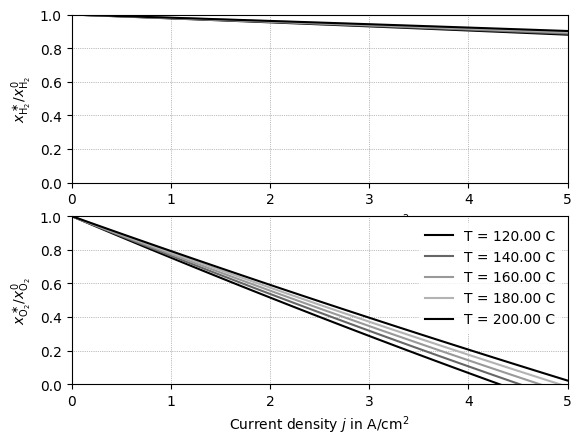

In [73]:
from phdtools.plots.fuel_cell import plot_interface_mole_fractions

fig = plot_interface_mole_fractions(
    fname_hydrogen=DataID(DataType.FIGURE, Chapter.METHODS, 16).get_path(
        fail_exists=False
    )
    / f"{FILE_DATE}_interface_mole_fractions_hydrogen.csv",
    fname_oxygen=DataID(DataType.FIGURE, Chapter.METHODS, 16).get_path(
        fail_exists=False
    )
    / f"{FILE_DATE}_interface_mole_fractions_oxygen.csv",
)

In [74]:
from phdtools.models.meck_2025 import (
    get_limitingCurrentDensityCathode,
    get_limitingCurrentDensityAnode,
)

temperatureKelvin = FUEL_CELL_TEMPERATURE_SI
pressureBar = 1.01325

limitingCurrentDensityCathodeSI = get_limitingCurrentDensityCathode(
    moleFractionIn=moleFractionCathodeIn,
    temperatureKelvin=temperatureKelvin,
    pressureBar=pressureBar,
)

limitingCurrentDensityAnodeSI = get_limitingCurrentDensityAnode(
    fun=diffusionModelAnode,
    moleFractionIn=moleFractionAnodeIn,
    temperatureKelvin=temperatureKelvin,
    pressureBar=pressureBar,
)

display(
    Latex(
        r"At $T = {}\,^\circ\mathrm{{C}}$ and $p = {}\,\mathrm{{bar}}$:".format(
            temperatureKelvin - 273.15, pressureSI * 1e-5
        )
    ),
    Latex(
        r"$j_{{L,C}} = {:.4f} \,\mathrm{{A/cm^2}}$".format(
            limitingCurrentDensityCathodeSI * 1e-4
        )
    ),
    Latex(
        r"$j_{{L,A}} = {:.4f} \,\mathrm{{A/cm^2}}$".format(
            limitingCurrentDensityAnodeSI * 1e-4
        )
    ),
)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

#### Conctentration losses
[back](#Table-of-contents)

*Nernstian losses*
$$
\ReversibleCellPotential = \StdCellPotential - \frac{\mathbf{R} T}{4\mathbf{F}}  \ln \frac{\Activity{\ce{H2O}}^2 }{\Activity{\ce{H2}}^2 \Activity{\ce{O2}}} 
$$

with 
$$
\Activity{\ce{H2}} = \frac{\Concentration{\ce{H2}}{}}{\MolarDensity}, \quad 
\Activity{\ce{O2}} = \frac{\Concentration{\ce{O2}}{}}{\MolarDensity}, \quad \text{and} \quad 
\Activity{\ce{H2O}} = \frac{\PartialPressure{\ce{H2O}}{}}{\SaturationVapourPressure{\ce{H2O}}} 
$$

*Reaction losses* 

Butler-Volmer equation
$$
\CurrentDensity{}
    = \ExchangeCurrentDensity
    \left[
    \frac{\Concentration{\ce{Red}}{}}{\Concentration{\ce{Red}}{0}}
      \exp{
        \left(
          (1 - \TransferCoef) 
          \frac
          {\ElectronsTransferred{}\FaradayConst\ActivationLosses}
          {\GasConst\Temperature{}}
        \right)
      } 
      - \frac{\Concentration{\ce{Ox}}{}}{\Concentration{\ce{Ox}}{0}}
      \exp{
        \left(
          -\TransferCoef
          \frac
          {\ElectronsTransferred{}\FaradayConst\ActivationLosses}
          {\GasConst\Temperature{}}
        \right)
      } 
    \right]
$$
Single term approximation for cathode reaction
$$
\frac{\CurrentDensity{}}{\ExchangeCurrentDensity}
    = -
      \frac{\Concentration{\ce{O2}}{}}{\Concentration{\ce{O2}}{0}} 
      \exp{
        \left(
          -\TransferCoef
          \frac
          {\ElectronsTransferred{}\FaradayConst\ActivationLosses}
          {\GasConst\Temperature{}}
        \right)
      }
\implies 
\ActivationLosses = \TransferCoef^{-1} \frac{\GasConst\Temperature{}}{\ElectronsTransferred{}\FaradayConst}
\left[\ln\left(\frac{\Concentration{\ce{O2}}{}}{\Concentration{\ce{O2}}{0}}\right) - \ln\left(-\frac{\CurrentDensity{}}{\ExchangeCurrentDensity}\right) \right]
$$

$$
\newcommand{\ConcentrationLosses}{\eta_\mathrm{conc}}
%
\ConcentrationLosses = c \ln \frac{\LimitingCurrentDensity}{\LimitingCurrentDensity - \CurrentDensity}
    \quad \text{where} \quad c = \frac{\GasConst\Temperature}{\StoichiometricNumber{}\FaradayConst} \left(1 + \TransferCoef{}^{-1}\right)
$$

**Note*: Empirically it is found that $c$ is ususally much larger than predicted.*

In [75]:
from phdtools.models.ohayre_2016 import concentrationOverpotentialModel

In [76]:
# request_free_id(DataType.FIGURE, Chapter.UNUSED)

In [77]:
data_id = DataID(DataType.FIGURE, Chapter.UNUSED, 21)


@auto_create_path
def save_concentration_overpotential(path):

    temperatureRangeSI = np.array([120, 140, 160, 180, 200]) + 273.15
    pressureBar = 1.01325

    limitingCurrentDensityValuesSI = np.full(len(temperatureRangeSI), np.nan)

    for num, temperatureKelvin in enumerate(temperatureRangeSI):
        limitingCurrentDensityValuesSI[num] = get_limitingCurrentDensityCathode(
            moleFractionIn=moleFractionCathodeIn,
            temperatureKelvin=temperatureKelvin,
            pressureBar=pressureBar,
        )

    transferCoefficientValues = transferCoefModel(temperatureRangeSI)[:, 1]

    currentDensityRangeSI = np.linspace(0, 2) * 1e4

    concentrationOverpotentialValuesSI = concentrationOverpotentialModel(
        currentDensitySI=currentDensityRangeSI,
        temperatureKelvin=temperatureRangeSI,
        limitingCurrentDensitySI=limitingCurrentDensityValuesSI,
        transferCoefficient=transferCoefficientValues,
        electronsTransferred=ELECTRONS_TRANSFERRED_ORR,
    )

    description = (
        "Concentration overpotential eta_conc for different temperatures T\n\n"
        "    eta_conc = R T / (F) (1/4 + aC^{-1}) ln (1 - j/jL) ) \n\n"
        "where R is the gas constant, F is the Faraday constant, jL is the\n"
        "cathode side limiting current density, and aC is the (cathode) charge\n"
        "transfer coefficient. Model simplifications follow O’Hayre, R.P. (2016).\n"
        "Parameters (from Zhang, 2007):\n"
    )
    for num, temperatureKelvin in enumerate(temperatureRangeSI):
        description += (
            f"T = {temperatureKelvin} K: "
            f"aC = {transferCoefficientValues[num]:.4f}; "
            f"jL = {limitingCurrentDensityValuesSI[num]*1e-4:.4f} A/cm2.\n"
        )
    description += (
        f"\n"
        f"References: \n"
        f"----------- \n"
        f"O’Hayre, R.P. (2016) Fuel cell fundamentals. Third edition. \n"
        f"   John Wiley & Sons. Available at: https://doi.org/10.1002/9781119191766.\n"
        f"\n"
        f"Zhang, Jianlu et al. (2007) “Polybenzimidazole-membrane-based PEM fuel cell\n"
        f"  in the temperature range of 120–200 °C,” Journal of Power Sources, 172(1),\n"
        f"  pp. 163–171. Available at: https://doi.org/10.1016/j.jpowsour.2007.07.047.\n"
    )

    fname = path / f"{TODAY}_concentration_overpotential.csv"

    with open(fname, "w+") as f:
        write_metadata(f, description)
        np.savetxt(
            f,
            np.c_[currentDensityRangeSI * 1e-4, concentrationOverpotentialValuesSI.T],
            header="j(A/cm2),"
            + ",".join(
                f"{temperatureKelvin - 273.15:.2f}"
                for temperatureKelvin in temperatureRangeSI
            ),
            delimiter=",",
            comments="",
        )


save_concentration_overpotential(
    data_id,
    doc=(
        r"Concentration overpotential from mass transfer limitations at the cathode vs. current density for different values of temperature; "
        r"determined as outlined in \cref{sec:methods-case-study-fuel-cell}"
    ),
    overwrite=overwrite,
)

In [78]:
!ls {DataID(DataType.FIGURE, Chapter.UNUSED, 21).get_path(fail_exists=False)}

260407_concentration_overpotential.csv


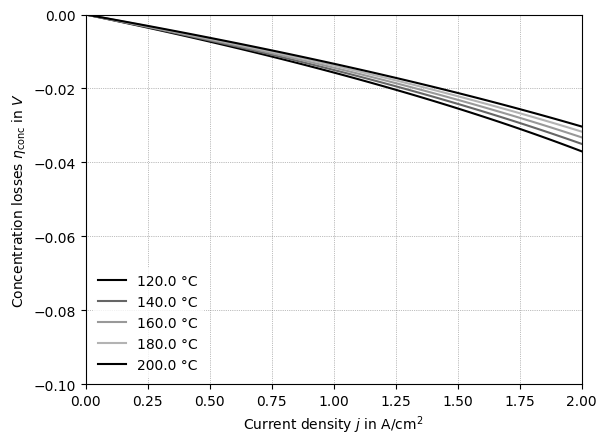

In [79]:
from phdtools.plots.fuel_cell import plot_concentration_overpotential

fig = plot_concentration_overpotential(
    fname=DataID(DataType.FIGURE, Chapter.UNUSED, 21).get_path(fail_exists=False)
    / f"{FILE_DATE}_concentration_overpotential.csv"
)

## Current-voltage characteristics
[back](#Table-of-contents)

In [80]:
from phdtools.models.ohayre_2016 import (
    fuelCellVoltageModel,
    ModelParameters as FuelCellParameters,
)

In [81]:
data_id = DataID(DataType.FIGURE, Chapter.METHODS, 17)


@auto_create_path
def save_current_voltage_curve(data_id):

    fname = data_id / f"{TODAY}_fuel_cell_characteristics.csv"

    pressureBar = ISO_STD_REF_PRESSURE_SI * 1e-5
    massFractionPhosphoricAcid = 0.9

    temperatureRangeSI = np.array([120, 140, 160, 180, 200]) + 273.15
    currentDensityRangeSI = np.geomspace(1e-8, 2 * 1e4, 250)

    # Feed composition
    moleFractionAnodeIn = np.zeros(len(Compound))
    moleFractionCathodeIn = np.zeros(len(Compound))

    moleFractionAnodeIn[Compound["H2(ref)"].value] = 1
    moleFractionCathodeIn[Compound["H2O1(g)"].value] = (
        0  # Zhang et al. (2007) used dry air
    )

    for c in Compound:
        if c.name != "H2O1(g)":
            moleFractionCathodeIn[c.value] = dryMoleFractionAir[c.value] * (
                1 - moleFractionCathodeIn[Compound["H2O1(g)"].value]
            )

    reversibleCellPotentialValuesSI = np.full(
        (len(temperatureRangeSI), len(currentDensityRangeSI)), np.nan
    )
    activationLossesCathodeValuesSI = np.full(
        (len(temperatureRangeSI), len(currentDensityRangeSI)), np.nan
    )
    activationLossesAnodeValuesSI = np.full(
        (len(temperatureRangeSI), len(currentDensityRangeSI)), np.nan
    )
    ohmicLossesValuesSI = np.full(
        (len(temperatureRangeSI), len(currentDensityRangeSI)), np.nan
    )
    concentrationOverpotentialValuesSI = np.full(
        (len(temperatureRangeSI), len(currentDensityRangeSI)), np.nan
    )

    fuelCellVoltageValuesSI = np.full(
        (len(temperatureRangeSI), len(currentDensityRangeSI)), np.nan
    )
    # powerDenistiyValuesSI = np.full((len(temperatureRangeSI),len(currentDensityRangeSI)), np.nan)

    for num, temperatureKelvin in enumerate(temperatureRangeSI):

        # Compute reversible cell potential
        activity = get_electrolyteFilmActivities(
            moleFractionAnodeIn,
            moleFractionCathodeIn,
            temperatureKelvin,
            pressureBar,
            massFractionPhosphoricAcid,
        )

        # assume constant electrolyte composition despite pH2O = 0 at the cathode
        vapourPressureOverPhosphoricAcidBar = (
            waterVapourPressureOverH3PO4Model(
                moleFractionH3PO4=get_moleFractionH3PO4(massFractionPhosphoricAcid),
                temperatureKelvin=temperatureKelvin,
            )[0, 0]
            * 1e-5
        )

        activity[Compound["H2O1(g)"].value] = vapourPressureOverPhosphoricAcidBar / (
            vapourPressureModel(temperatureKelvin)[0] * 1e-5
        )

        # assume 1% rel. humidity at 15 C
        # activity[Compound["H2O1(g)"].value] = (
        #     0.01*vapourPressureModel(ISO_STD_REF_TEMPERATURE_SI)[0] / (vapourPressureModel(temperatureKelvin)[0])
        # )

        reversibleCellPotentialValuesSI[num] = reversibleCellPotentialModel(
            temperatureKelvin, activity
        )

    exchangeCurrentDensityAnodeSI = exchangeCurrentDensityModel(
        params, temperatureRangeSI
    )[:, 0]
    transferCoefficientAnode = transferCoefModel(temperatureRangeSI)[:, 0]

    exchangeCurrentDensityCathodeSI = exchangeCurrentDensityModel(
        params, temperatureRangeSI
    )[:, 1]
    transferCoefficientCathode = transferCoefModel(temperatureRangeSI)[:, 1]

    areaSpecificResistanceSI = MEMBRANE_THICKNESS_SI / conductivityModel(
        params, temperatureRangeSI
    )

    limitingCurrentDensityValuesSI = np.full(len(temperatureRangeSI), np.nan)
    for num, temperatureKelvin in enumerate(temperatureRangeSI):
        limitingCurrentDensityValuesSI[num] = get_limitingCurrentDensityCathode(
            moleFractionIn=moleFractionCathodeIn,
            temperatureKelvin=temperatureKelvin,
            pressureBar=pressureBar,
        )

    for num, temperatureKelvin in enumerate(temperatureRangeSI):
        activationLossesCathodeValuesSI[num] = activationOverpotentialModel(
            currentDensitySI=-currentDensityRangeSI,
            temperatureKelvin=temperatureKelvin,
            transferCoefficient=transferCoefficientCathode[num],
            exchangeCurrentDensitySI=exchangeCurrentDensityCathodeSI[num],
            electronsTransferred=ELECTRONS_TRANSFERRED_ORR,
            model="tafel",
        )
        activationLossesAnodeValuesSI[num] = activationOverpotentialModel(
            currentDensitySI=currentDensityRangeSI,
            temperatureKelvin=temperatureKelvin,
            transferCoefficient=transferCoefficientAnode[num],
            exchangeCurrentDensitySI=exchangeCurrentDensityAnodeSI[num],
            electronsTransferred=ELECTRONS_TRANSFERRED_HOR,
            model="butler-volmer",
        )

    ohmicLossesValuesSI = (
        areaSpecificResistanceSI[:, np.newaxis] * currentDensityRangeSI
    )

    concentrationOverpotentialValuesSI = concentrationOverpotentialModel(
        currentDensitySI=currentDensityRangeSI,
        temperatureKelvin=temperatureRangeSI,
        limitingCurrentDensitySI=limitingCurrentDensityValuesSI,
        transferCoefficient=transferCoefficientCathode,
        electronsTransferred=ELECTRONS_TRANSFERRED_ORR,
    )

    fuelCellVoltageValuesSI = (
        reversibleCellPotentialValuesSI
        + activationLossesCathodeValuesSI
        + concentrationOverpotentialValuesSI
        - ohmicLossesValuesSI
    )  # -activationLossesAnodeValuesSI

    description = (
        (
            f"PA-PBI HT fuel cell polarization curve at different termperatures T:\n\n"
            f"   U = Ecell − 1/a RT/F ln(j/j0) + RT/F (1/4 + 1/a) ln(1 − j/jL) - Rs j \n\n"
        )
        + (
            f"The reversible cell potential assumes a constant PA concentration\n"
            f"of w ={massFractionPhosphoricAcid} in the electrolyte film.\n"
            f"The inlet pressure p = {pressureBar} bar on both sides.\n"
            f"The gas composition at the anode is:\n"
            f"  x_CH4,0 = {moleFractionAnodeIn[Compound["C1H4(g)"].value]:.4f};\n"
            f"  x_CO,0 = {moleFractionAnodeIn[Compound["C1O1(g)"].value]:.4f};\n"
            f"  x_CO2,0 = {moleFractionAnodeIn[Compound["C1O2(g)"].value]:.4f};\n"
            f"  x_H2,0 = {moleFractionAnodeIn[Compound["H2(ref)"].value]:.4f};\n"
            f"  x_H2O,0 = {moleFractionAnodeIn[Compound["H2O1(g)"].value]:.4f}.\n"
            f"The gas composition at the cathode is:\n"
            f"  x_N2,0 = {moleFractionCathodeIn[Compound["N2(ref)"].value]:.4f};\n"
            f"  x_O2,0 = {moleFractionCathodeIn[Compound["O2(ref)"].value]:.4f};\n"
            f"  x_H2O,0 = {moleFractionCathodeIn[Compound["H2O1(g)"].value]:.4f}.\n"
        )
        + " Reversivle cell potential Ecell(T):\n"
        + "\n".join(
            f"    Ecell(T={T} K) = {reversibleCellPotentialValuesSI[num,0]:.4f} V"
            for num, T in enumerate(temperatureRangeSI)
        )
        + "\n"
        + (
            f"The transfer coefficient a = 0.001678 T, membrane resistance Rs, and \n"
            f"exchange current density j0 are modelled after Zhang, Jianlu et al. (2007):\n"
        )
        + " Exchange current density j0(T):\n"
        + "\n".join(
            f"    j0(T={T} K) = {exchangeCurrentDensityCathodeSI[num]*1e-4:.4g} A/cm2"
            for num, T in enumerate(temperatureRangeSI)
        )
        + "\n"
        + "  transfer coefficient a(T):\n"
        + "\n".join(
            f"    a(T={T} K) = {transferCoefficientCathode[num]:.4g}"
            for num, T in enumerate(temperatureRangeSI)
        )
        + "\n"
        + " Membrane resistance Rs(T):\n"
        + "\n".join(
            f"    Rs(T={T} K) = {areaSpecificResistanceSI[num]*1e4:.4g} Ohm cm2"
            for num, T in enumerate(temperatureRangeSI)
        )
        + "\n"
        + (
            f"The limiting current density is calculated from the Stefan-Maxwell\n"
            f"diffusion model. "
        )
        + "Limiting current density jL(T):\n"
        + "\n".join(
            f"    jL(T={T} K) = {limitingCurrentDensityValuesSI[num]*1e-4:.4g} A/cm2"
            for num, T in enumerate(temperatureRangeSI)
        )
        + "\n"
        + (
            "\n"
            "References: \n"
            "----------- \n"
            "Allison, T. (2013) ‘NIST-JANAF Thermochemical Tables - SRD 13’.\n"
            "    National Institute of Standards and Technology. Available at: https://doi.org/10.18434/T42S31 \n\n"
            "Atkins, P.W., Paula, J.D. and Keeler, J. (2023) Atkins’ Physical chemistry. Twelfth edition. \n"
            "    New York NY: Oxford University Press.\n\n"
            "Klinedinst, K. et al. (1974) “Oxygen solubility and diffusivity in hot concentrated H3PO4,” Journal \n"
            "   of Electroanalytical Chemistry and Interfacial Electrochemistry, 57(3), pp. 281–289. Available at: \n"
            "   https://doi.org/10.1016/S0022-0728(74)80053-7\n\n"
            "Linstrom, P. (1997) “NIST Chemistry WebBook, NIST Standard Reference”\n"
            "   Database 69.National Institute of Standards and Technology \n"
            "   Available at: https://doi.org/10.18434/T4D303. \n\n"
            "MacDonald, D.I. and Boyack, J.R. (1969) “Density, electrical conductivity, and vapor pressure of \n"
            "    concentrated phosphoric acid,” Journal of Chemical & Engineering Data, 14(3), pp. 380–384. \n"
            "    Available at: https://doi.org/10.1021/je60042a013.\n\n"
            "Mamlouk, M., Sousa, T. and Scott, K. (2011) “A High Temperature Polymer Electrolyte Membrane Fuel\n"
            "    Cell Model for Reformate Gas,” International Journal of Electrochemistry, 2011, pp. 1–18. \n"
            "    Available at: https://doi.org/10.4061/2011/520473.\n\n"
            "O’Hayre, R.P. (2016) Fuel cell fundamentals. Third edition. \n"
            "   John Wiley & Sons. Available at: https://doi.org/10.1002/9781119191766.\n\n"
            "Slattery, J.C. and Bird, R.B. (1958) “Calculation of the diffusion coef-\n"
            "  ficient of dilute gases and of the self‐diffusion coefficient of dense\n"
            "  gases,” AIChE Journal, 4(2), pp. 137–142. Available at: \n"
            "  https://doi.org/10.1002/aic.690040205.\n\n"
            "Zhang, Jianlu et al. (2007) “Polybenzimidazole-membrane-based PEM fuel cell\n"
            "  in the temperature range of 120–200 °C,” Journal of Power Sources, 172(1),\n"
            "  pp. 163–171. Available at: https://doi.org/10.1016/j.jpowsour.2007.07.047.\n"
        )
    )

    with open(fname, "w+") as f:
        write_metadata(f, description)
        np.savetxt(
            f,
            np.c_[currentDensityRangeSI * 1e-4, fuelCellVoltageValuesSI.T],
            header="j(A/cm2),"
            + ",".join("T = {} K".format(T) for T in temperatureRangeSI),
            comments="",
            delimiter=",",
        )


save_current_voltage_curve(
    data_id,
    doc=r"Calculated values for cell potential vs current density at different temperatures according to the \gls{PA-PBI} fuel cell model developed in \cref{sec:methods-case-study-fuel-cell}",
    overwrite=overwrite,
)

In [82]:
!ls {DataID(DataType.FIGURE, Chapter.METHODS, 17).get_path(fail_exists=False)}

260407_fuel_cell_characteristics.csv


In [83]:
from phdtools.plots.fuel_cell import (
    plot_fuel_cell_characteristic,
    plot_polarization_curve,
)

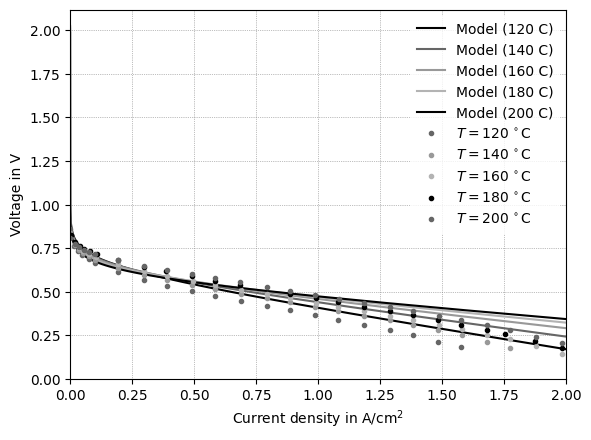

In [84]:
fig = plot_polarization_curve(
    fname=DataID(DataType.FIGURE, Chapter.METHODS, 17).get_path(fail_exists=False)
    / f"{FILE_DATE}_fuel_cell_characteristics.csv"
)

## References
[back](#Table-of-contents)

1. Amphlett, J.C. et al. (1994) ‘Parametric modelling of the performance of a 5-kW proton-exchange membrane fuel cell stack’, Journal of Power Sources, 49(1–3), pp. 349–356. Available at: https://doi.org/10.1016/0378-7753(93)01835-6.
2. Mann, R.F. et al. (2000) ‘Development and application of a generalised steady-state electrochemical model for a PEM fuel cell’, Journal of Power Sources, 86(1–2), pp. 173–180. Available at: https://doi.org/10.1016/S0378-7753(99)00484-X.
3. Mann, R.F. et al. (2006) ‘Henry’s Law and the solubilities of reactant gases in the modelling of PEM fuel cells’, Journal of Power Sources, 161(2), pp. 768–774. Available at: https://doi.org/10.1016/j.jpowsour.2006.05.054.
4. Mamlouk, M., Sousa, T. and Scott, K. (2011) “A High Temperature Polymer Electrolyte Membrane Fuel Cell Model for Reformate Gas,” International Journal of Electrochemistry, 2011, pp. 1–18. Available at: https://doi.org/10.4061/2011/520473.
5. O’Hayre, R.P. (2016) Fuel cell fundamentals. Third edition. Hoboken, New Jersey: John Wiley & Sons. Available at: https://doi.org/10.1002/9781119191766.
6. Slattery, J.C. and Bird, R.B. (1958) “Calculation of the diffusion coefficient of dilute gases and of the self‐diffusion coefficient of dense gases,” AIChE Journal, 4(2), pp. 137–142. Available at: https://doi.org/10.1002/aic.690040205.
7. Stuve, E.M. (2014) “Overpotentials in Electrochemical Cells,” in G. Kreysa, K. Ota, and R.F. Savinell (eds.) Encyclopedia of Applied Electrochemistry. New York, NY: Springer New York, pp. 1445–1453. Available at: https://doi.org/10.1007/978-1-4419-6996-5_330.